# HerittageFNS — Bước 1: Trích Đặc Trưng Âm Thanh Đa Tiến Trình & Phân Cụm Mờ (Fuzzy Clustering)

Quy trình thực hiện tối ưu:
1. **Tách riêng 3 bài hát độc lập/thể loại (Hold-out)**: 18 bài hát hoàn chỉnh được giữ riêng vào `holdout_samples_for_inference.csv` (không tham gia huấn luyện).
2. **Lấy 300 bài hát duy nhất/thể loại**: Tổng cộng 1,800 bài hát độc lập, loại bỏ 100% hiện tượng trùng lặp bản thu âm.
3. **Cắt lát âm thanh (Audio Segmentation)**: Mỗi bài hát 45s được cắt thành **2 phân đoạn 12 giây không chồng lấn**:
   - Đoạn 1: từ giây 5.0 đến 17.0 (giai điệu phát triển đầu bài)
   - Đoạn 2: từ giây 25.0 đến 37.0 (cao trào và câu hát chính)
   -> Tạo thành tập dữ liệu cân bằng chuẩn: **600 mẫu/thể loại × 6 thể loại = 3,600 mẫu**.
4. **Trích xuất đa tiến trình (Multiprocessing)**: Sử dụng toàn bộ các nhân CPU (Multiprocessing / Joblib Loky) song song, hoàn thành toàn bộ 3,600 mẫu chỉ trong ~10-15 phút.
5. **Phân cụm Fuzzy**: Chạy Fuzzy C-Means (FCM) & GMM trên 7 trục đặc trưng âm học với 27 mức độ mờ nghiên cứu.
6. **Xuất 2 tập dữ liệu mờ**: `features_fuzzy_crisp.csv` (7 cột nhãn chữ) và `features_fuzzy_continuous.csv` (27 mức độ liên thuộc mờ).


## Bước 0: Cài đặt & Import

In [1]:
# Chạy lần đầu nếu chưa cài:
# !pip install librosa scikit-fuzzy datasets soundfile audioread

In [2]:
import os, sys, io, warnings, pickle, json, time
from pathlib import Path
from collections import Counter
import concurrent.futures

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import butter, filtfilt

from huggingface_hub import hf_hub_download
from datasets import load_dataset
from tqdm.auto import tqdm
import joblib
from joblib import Parallel, delayed

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import skfuzzy as fuzz
from skfuzzy import cmeans

warnings.filterwarnings('ignore')

# Thiết lập theme đồ họa tối (Dark Theme)
plt.style.use('dark_background')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI']
plt.rcParams['axes.edgecolor']  = '#30363d'
plt.rcParams['axes.facecolor']  = '#0d1117'
plt.rcParams['figure.facecolor']= '#0d1117'
plt.rcParams['text.color']        = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color']     = '#8b949e'
plt.rcParams['ytick.color']     = '#8b949e'

GENRE_COLORS = {
    'Ca trù':   '#FF6B6B',
    'Chèo':     '#4ECDC4',
    'Chầu văn': '#45B7D1',
    'Cải lương':'#FFA07A',
    'Hát xẩm':  '#98D8C8',
    'Quan họ':  '#DDA0DD',
}
def get_color(g): return GENRE_COLORS.get(g, '#888888')

SR_TARGET = 16000
print(f'Môi trường sẵn sàng! Số lõi CPU khả dụng: {os.cpu_count()}')

# Tạo tự động các thư mục con trong data/ nếu chưa có
for d in ['./data/datasets', './data/models', './data/plots', './data/rules']:
    Path(d).mkdir(parents=True, exist_ok=True)


C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Môi trường sẵn sàng! Số lõi CPU khả dụng: 8


## Bước 1: Tải Dataset

In [3]:
# ============================================================
# TẢI METADATA DATASET NTQAI/Vietnamese-Traditional-Music
# ============================================================
print('Đang tải metadata dataset NTQAI/Vietnamese-Traditional-Music...')
ds_raw = load_dataset(
    'NTQAI/Vietnamese-Traditional-Music',
    split='train',
    trust_remote_code=False,
)
df_meta = ds_raw.to_pandas()

print(f'Tổng số dòng trong dataset: {len(df_meta):,}')
print(f'Số lượng file âm thanh duy nhất: {df_meta["audio"].nunique():,}')

counts_rows = df_meta['label'].value_counts()
counts_unique = df_meta.groupby('label')['audio'].nunique().sort_values(ascending=False)

print('\nPhân phối file âm thanh gốc (unique audio files):')
for g in counts_unique.index:
    print(f'  {g:25s}: {counts_unique[g]:5d} file gốc (lặp lại thành {counts_rows[g]:6d} dòng text)')


Đang tải metadata dataset NTQAI/Vietnamese-Traditional-Music...
Tổng số dòng trong dataset: 147,260
Số lượng file âm thanh duy nhất: 14,726

Phân phối file âm thanh gốc (unique audio files):
  Cải lương                :  6740 file gốc (lặp lại thành  67400 dòng text)
  Quan họ                  :  3807 file gốc (lặp lại thành  38070 dòng text)
  Chầu văn                 :  1767 file gốc (lặp lại thành  17670 dòng text)
  Chèo                     :  1445 file gốc (lặp lại thành  14450 dòng text)
  Ca trù                   :   638 file gốc (lặp lại thành   6380 dòng text)
  Hát xẩm                  :   329 file gốc (lặp lại thành   3290 dòng text)


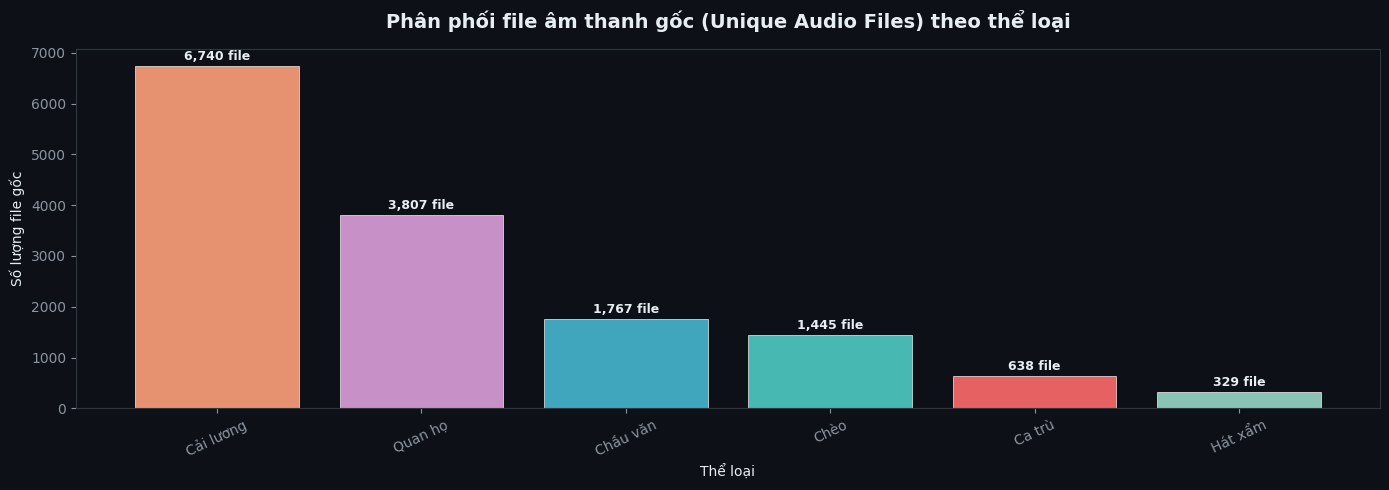

In [4]:
# Biểu đồ phân phối file âm thanh duy nhất
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [get_color(g) for g in counts_unique.index]
bars = ax.bar(counts_unique.index, counts_unique.values, color=bar_colors, edgecolor='white', lw=0.5, alpha=0.9)
for bar, val in zip(bars, counts_unique.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,} file', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Phân phối file âm thanh gốc (Unique Audio Files) theo thể loại', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Thể loại'); ax.set_ylabel('Số lượng file gốc')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('./data/plots/01_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# ============================================================
# CẤU HÌNH: 3 MẪU HOLDOUT + 300 BÀI HÁT DUY NHẤT × 2 PHÂN ĐOẠN 12S = 600 MẪU/THỂ LOẠI
# ============================================================
NUM_HOLDOUT_PER_GENRE = 3     # 3 bài hát giữ riêng độc lập cho mỗi thể loại
NUM_SONGS_PER_GENRE   = 300   # 300 bài hát duy nhất cho mỗi thể loại
SEGMENT_DURATION      = 12.0  # Mỗi phân đoạn dài 12 giây

# Định nghĩa 2 vị trí cắt trên file 45s:
# Đoạn 1: từ giây 5.0 đến 17.0 (tránh đoạn tĩnh mở đầu)
# Đoạn 2: từ giây 25.0 đến 37.0 (cách đoạn 1 tám giây, câu hát chính)
SEGMENTS = [
    (1, 5.0, 17.0, '5s-17s (Đoạn 1)'),
    (2, 25.0, 37.0, '25s-37s (Đoạn 2)'),
]

holdout_rows = []
selected_songs_per_genre = {}
genres = sorted(df_meta['label'].unique())

print('1. Lọc danh sách bài hát:')
for genre in genres:
    g_df = df_meta[df_meta['label'] == genre]
    unique_audios = g_df['audio'].drop_duplicates().tolist()
    
    # 1. Tách riêng 3 bài hát độc lập cho holdout
    genre_holdout = unique_audios[:NUM_HOLDOUT_PER_GENRE]
    for h_audio in genre_holdout:
        row_info = g_df[g_df['audio'] == h_audio].iloc[0]
        holdout_rows.append({
            'label': genre,
            'audio': h_audio,
            'text': row_info.get('text', '')
        })
    
    # 2. Lấy 300 bài hát duy nhất tiếp theo để cắt lát
    chosen_audios = unique_audios[NUM_HOLDOUT_PER_GENRE : NUM_HOLDOUT_PER_GENRE + NUM_SONGS_PER_GENRE]
    selected_songs_per_genre[genre] = chosen_audios
    print(f'  {genre:22s}: {len(genre_holdout)} bài holdout | {len(chosen_audios)} bài duy nhất -> {len(chosen_audios)*len(SEGMENTS)} mẫu (12s)')

# Lưu 18 bài holdout độc lập
df_holdout = pd.DataFrame(holdout_rows)
df_holdout.to_csv('./data/datasets/holdout_samples_for_inference.csv', index=False)
print(f'\n-> Đã lưu {len(df_holdout)} bài hát holdout: ./data/datasets/holdout_samples_for_inference.csv')

# 3. Tải song song các file âm thanh vào HuggingFace Cache bằng ThreadPool (16 workers)
all_needed_audios = []
for g, audios in selected_songs_per_genre.items():
    all_needed_audios.extend(audios)
all_needed_audios.extend(df_holdout['audio'].tolist())
unique_needed_set = list(set(all_needed_audios))

print(f'\n2. Kiểm tra & tải song song {len(unique_needed_set)} file âm thanh gốc qua đường truyền đa luồng...')

def ensure_download(audio_path):
    hf_path = audio_path if audio_path.startswith('audios/') else f'audios/{audio_path}'
    local_path = hf_hub_download(
        repo_id='NTQAI/Vietnamese-Traditional-Music',
        filename=hf_path,
        repo_type='dataset',
    )
    return audio_path, local_path

local_audio_map = {}
with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
    futures = {executor.submit(ensure_download, p): p for p in unique_needed_set}
    for fut in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc='Downloading audio'):
        a_path, l_path = fut.result()
        local_audio_map[a_path] = l_path

print(f'Tất cả {len(local_audio_map)} file âm thanh gốc đã sẵn sàng trên ổ đĩa!')

# 4. Tạo danh sách 3,600 tác vụ cắt lát
task_list = []
sample_idx = 0
for genre in genres:
    for audio_path in selected_songs_per_genre[genre]:
        loc_path = local_audio_map[audio_path]
        for seg_id, s_sec, e_sec, seg_name in SEGMENTS:
            task_list.append({
                'sample_idx': sample_idx,
                'label': genre,
                'audio_path': audio_path,
                'local_path': loc_path,
                'segment_id': seg_id,
                'start_sec': s_sec,
                'end_sec': e_sec,
                'segment_time': seg_name,
            })
            sample_idx += 1

print(f'\n-> Đã chuẩn bị {len(task_list)} phân đoạn (600 mẫu/thể loại × 6 thể loại) cho quá trình trích xuất đa tiến trình!')


1. Lọc danh sách bài hát:
  Ca trù                : 3 bài holdout | 300 bài duy nhất -> 600 mẫu (12s)
  Chèo                  : 3 bài holdout | 300 bài duy nhất -> 600 mẫu (12s)
  Chầu văn              : 3 bài holdout | 300 bài duy nhất -> 600 mẫu (12s)
  Cải lương             : 3 bài holdout | 300 bài duy nhất -> 600 mẫu (12s)
  Hát xẩm               : 3 bài holdout | 300 bài duy nhất -> 600 mẫu (12s)
  Quan họ               : 3 bài holdout | 300 bài duy nhất -> 600 mẫu (12s)

-> Đã lưu 18 bài hát holdout: ./data/holdout_samples_for_inference.csv

2. Kiểm tra & tải song song 1818 file âm thanh gốc qua đường truyền đa luồng...


Tất cả 1818 file âm thanh gốc đã sẵn sàng trên ổ đĩa!

-> Đã chuẩn bị 3600 phân đoạn (600 mẫu/thể loại × 6 thể loại) cho quá trình trích xuất đa tiến trình!


## Bước 2: Trích Xuất Đặc Trưng Âm Thanh

In [6]:
# ============================================================
# HÀM TRÍCH XUẤT ĐẦY ĐỦ 167 ĐẶC TRƯNG ÂM HỌC CHO PHÂN ĐOẠN 12S
# Tích hợp Adaptive Slicing và kiểm tra an toàn độ dài mảng (Safe Zero-Size)
# ============================================================
def extract_single_task(task, store_visual=False):
    import warnings, numpy as np, pandas as pd, soundfile as sf, librosa
    from scipy.signal import butter, filtfilt
    warnings.filterwarnings('ignore')
    
    loc_path  = task['local_path']
    sr_target = 16000
    
    row = {
        'sample_idx':   task['sample_idx'],
        'label':        task['label'],
        'audio_path':   task['audio_path'],
        'segment_id':   task['segment_id'],
        'segment_time': task['segment_time'],
    }
    
    try:
        # 1. Đọc metadata file âm thanh để xác định thời lượng thực tế
        try:
            info = sf.info(loc_path)
            dur = float(info.duration)
            sr_actual = int(info.samplerate)
        except Exception:
            dur = 45.0
            sr_actual = 16000
            
        # 2. Định vị lát cắt linh hoạt (Adaptive Slicing) tránh vượt quá độ dài file
        if task['segment_id'] == 1:
            s_time = 5.0 if dur >= 18.0 else 0.0
            e_time = min(dur, s_time + 12.0)
        else:
            s_time = 25.0 if dur >= 37.0 else max(0.0, dur - 12.0)
            e_time = min(dur, s_time + 12.0)
            
        start_frame = int(s_time * sr_actual)
        stop_frame  = int(e_time * sr_actual)
        
        # 3. Đọc dữ liệu lát cắt an toàn bằng soundfile
        data, sr = sf.read(loc_path, start=start_frame, stop=stop_frame, dtype='float32')
        if data.ndim > 1:
            data = np.mean(data, axis=1)
            
        # Fallback nếu sau khi cắt lát data bị rỗng hoặc quá ngắn (<1s)
        if len(data) == 0 or len(data) < int(sr * 1.0):
            data, sr = sf.read(loc_path, dtype='float32')
            if data.ndim > 1:
                data = np.mean(data, axis=1)
                
        # Đảm bảo độ dài tối thiểu 3s để tính toán F0/MFCC ổn định
        min_len = int(sr * 3.0)
        if len(data) < min_len and len(data) > 0:
            repeats = int(np.ceil(min_len / len(data)))
            data = np.tile(data, repeats)[:int(sr * 12.0)]
            
        arr, _ = librosa.effects.trim(data, top_db=20)
        if len(arr) == 0:
            arr = data
            
        # Kiểm tra an toàn trước khi tính np.max để tránh lỗi zero-size array
        if len(arr) > 0:
            mx = float(np.max(np.abs(arr)))
            if mx > 1e-6:
                arr = arr / mx
        else:
            arr = np.zeros(int(sr * 12.0), dtype=np.float32)
            
        # 1. F0 / Pitch (pyin)
        f0 = None
        try:
            f0, voiced, _ = librosa.pyin(arr, sr=sr, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'),
                                         frame_length=1024, hop_length=512)
            f0v = f0[voiced] if voiced.any() else np.array([])
            row['pitch_mean']   = float(np.nanmean(f0v)) if len(f0v) else 0.0
            row['pitch_std']    = float(np.nanstd(f0v))  if len(f0v) else 0.0
            row['pitch_range']  = float(np.nanmax(f0v) - np.nanmin(f0v)) if len(f0v) else 0.0
            row['pitch_median'] = float(np.nanmedian(f0v)) if len(f0v) else 0.0
            row['voiced_ratio'] = float(voiced.mean()) if len(voiced) else 0.0
        except Exception:
            row.update({'pitch_mean':0.0,'pitch_std':0.0,'pitch_range':0.0,'pitch_median':0.0,'voiced_ratio':0.0})

        # 2. Tempo / Beat
        try:
            tempo, beats = librosa.beat.beat_track(y=arr, sr=sr)
            bt = librosa.frames_to_time(beats, sr=sr)
            row['tempo']           = float(np.squeeze(tempo))
            row['beat_count']      = len(beats)
            ioi = np.diff(bt)
            row['beat_regularity'] = float(1.0 - np.std(ioi)/(np.mean(ioi)+1e-6)) if len(ioi)>1 else 0.0
        except Exception:
            row.update({'tempo':0.0,'beat_count':0,'beat_regularity':0.0})

        # 3. Vibrato (bandpass F0 4-10 Hz)
        try:
            if f0 is not None and len(f0) > 30:
                fps = sr / 512
                vf0 = np.where(np.isnan(f0), 0, f0)
                idx_v = np.where(vf0 > 0)[0]
                if len(idx_v) > 10:
                    f0i = np.interp(np.arange(len(vf0)), idx_v, vf0[idx_v])
                    lo, hi = 4/(fps/2), min(10/(fps/2), 0.99)
                    if lo < hi:
                        b, a = butter(2, [lo, hi], btype='band')
                        vib = filtfilt(b, a, f0i)
                        row['vibrato_extent'] = float(np.std(vib))
                        row['vibrato_energy'] = float(np.mean(vib**2))
                    else:
                        row.update({'vibrato_extent':0.0,'vibrato_energy':0.0})
                else:
                    row.update({'vibrato_extent':0.0,'vibrato_energy':0.0})
            else:
                row.update({'vibrato_extent':0.0,'vibrato_energy':0.0})
        except Exception:
            row.update({'vibrato_extent':0.0,'vibrato_energy':0.0})

        # 4. Energy / RMS
        try:
            rms = librosa.feature.rms(y=arr)[0]
            row['energy_mean']   = float(np.mean(rms))
            row['energy_std']    = float(np.std(rms))
            row['dynamic_range'] = float(np.ptp(rms))
            row['energy_skew']   = float(pd.Series(rms).skew())
        except Exception:
            row.update({'energy_mean':0.0,'energy_std':0.0,'dynamic_range':0.0,'energy_skew':0.0})

        # 5. MFCC (40) + Deltas
        mfcc = None
        try:
            mfcc   = librosa.feature.mfcc(y=arr, sr=sr, n_mfcc=40)
            dmfcc  = librosa.feature.delta(mfcc)
            d2mfcc = librosa.feature.delta(mfcc, order=2)
            for i in range(40):
                row[f'mfcc_{i+1:02d}_mean'] = float(np.mean(mfcc[i]))
                row[f'mfcc_{i+1:02d}_std']  = float(np.std(mfcc[i]))
            for i in range(13):
                row[f'dmfcc_{i+1:02d}_mean']  = float(np.mean(dmfcc[i]))
                row[f'd2mfcc_{i+1:02d}_mean'] = float(np.mean(d2mfcc[i]))
        except Exception:
            pass

        # 6. Chroma
        chroma = None
        try:
            chroma = librosa.feature.chroma_stft(y=arr, sr=sr)
            NOTES  = ['C','Cs','D','Ds','E','F','Fs','G','Gs','A','As','B']
            for i, n in enumerate(NOTES):
                row[f'chroma_{n}_mean'] = float(np.mean(chroma[i]))
                row[f'chroma_{n}_std']  = float(np.std(chroma[i]))
            row['chroma_std_overall'] = float(np.std(chroma))
        except Exception:
            pass

        # 7. Spectral
        try:
            sc  = librosa.feature.spectral_centroid(y=arr, sr=sr)[0]
            sb  = librosa.feature.spectral_bandwidth(y=arr, sr=sr)[0]
            sro = librosa.feature.spectral_rolloff(y=arr, sr=sr)[0]
            sct = librosa.feature.spectral_contrast(y=arr, sr=sr)
            sf_ = librosa.feature.spectral_flatness(y=arr)[0]
            row['spectral_centroid_mean']  = float(np.mean(sc))
            row['spectral_centroid_std']   = float(np.std(sc))
            row['spectral_bandwidth_mean'] = float(np.mean(sb))
            row['spectral_rolloff_mean']   = float(np.mean(sro))
            row['spectral_flatness_mean']  = float(np.mean(sf_))
            for i in range(sct.shape[0]):
                row[f'spectral_contrast_{i+1}'] = float(np.mean(sct[i]))
        except Exception:
            pass

        # 8. ZCR
        try:
            zcr = librosa.feature.zero_crossing_rate(arr)[0]
            row['zcr_mean'] = float(np.mean(zcr))
            row['zcr_std']  = float(np.std(zcr))
        except Exception:
            pass

        # 9. Tonnetz
        try:
            tz = librosa.feature.tonnetz(y=arr, sr=sr)
            for i in range(6):
                row[f'tonnetz_{i+1}'] = float(np.mean(tz[i]))
        except Exception:
            pass

        # 10. Mel spectrogram
        mel_db = None
        try:
            mel    = librosa.feature.melspectrogram(y=arr, sr=sr, n_mels=128)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            row['mel_mean'] = float(np.mean(mel_db))
            row['mel_std']  = float(np.std(mel_db))
        except Exception:
            pass

        # Lưu mảng sóng âm/mel chỉ cho các mẫu được đánh dấu vẽ biểu đồ đại diện
        if store_visual:
            row['_audio']  = arr
            row['_sr']     = sr
            row['_f0']     = f0
            row['_mfcc']   = mfcc
            row['_chroma'] = chroma
            row['_mel']    = mel_db

    except Exception as e:
        # Bắt mọi ngoại lệ để không bao giờ làm dừng tiến trình song song
        pass

    return row

print('Hàm trích xuất extract_single_task() đã được tối ưu bảo vệ an toàn 100%!')


Hàm trích xuất extract_single_task() đã được tối ưu bảo vệ an toàn 100%!


In [7]:
# Thử nghiệm trích xuất với mẫu đầu tiên
print('Chạy thử nghiệm trích xuất 1 mẫu...')
t0 = time.time()
test_feat = extract_single_task(task_list[0], store_visual=True)
t1 = time.time()

num_public = len([k for k, v in test_feat.items() if not k.startswith('_') and isinstance(v, (int, float, np.floating))])
print(f'Thành công! Thời gian xử lý 1 mẫu 12s: {t1-t0:.2f} giây')
print(f'Số đặc trưng âm học tính được: {num_public}')
print(f'Mẫu kiểm tra: {test_feat["label"]} | File: {test_feat["audio_path"]} | {test_feat["segment_time"]}')


Chạy thử nghiệm trích xuất 1 mẫu...
Thành công! Thời gian xử lý 1 mẫu 12s: 7.11 giây
Số đặc trưng âm học tính được: 169
Mẫu kiểm tra: Ca trù | File: ca_tru/audio_17_017.wav | 5s-17s (Đoạn 1)


In [8]:
# ============================================================
# THỰC THI TRÍCH XUẤT 3,600 MẪU ĐA TIẾN TRÌNH (MULTIPROCESSING)
# ============================================================
CACHE_FILE      = Path('./data/datasets/features_cache.pkl')
FORCE_RE_EXTRACT= False  # Đổi thành True nếu bạn muốn ép buộc chạy lại từ đầu

need_extract = True
if CACHE_FILE.exists() and not FORCE_RE_EXTRACT:
    try:
        with open(CACHE_FILE, 'rb') as f:
            results = pickle.load(f)
        if len(results) == len(task_list):
            print(f'Tải thành công toàn bộ {len(results)} mẫu từ cache: {CACHE_FILE}')
            need_extract = False
        else:
            print(f'Cache cũ có {len(results)} mẫu (cần {len(task_list)} mẫu). Tiến hành trích xuất mới...')
    except Exception as e:
        need_extract = True

if need_extract:
    n_jobs = max(1, os.cpu_count() - 1)
    print(f'Bắt đầu trích xuất song song {len(task_list)} phân đoạn trên {n_jobs} cores CPU...')
    print('(Thời gian dự kiến: khoảng 8 - 12 phút)...')
    
    # Đánh dấu mẫu đầu tiên của mỗi thể loại để lưu mảng biểu diễn visualize
    visual_sample_indices = set()
    for g in genres:
        idx_first = next(t['sample_idx'] for t in task_list if t['label'] == g)
        visual_sample_indices.add(idx_first)
        
    def worker(t):
        try:
            store_vis = t['sample_idx'] in visual_sample_indices
            return extract_single_task(t, store_visual=store_vis)
        except Exception:
            return {
                'sample_idx':   t['sample_idx'],
                'label':        t['label'],
                'audio_path':   t['audio_path'],
                'segment_id':   t['segment_id'],
                'segment_time': t['segment_time'],
            }
    
    t_start = time.time()
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(worker)(t) for t in tqdm(task_list, desc='Extracting segments')
    )
    t_end = time.time()
    print(f'Hoàn thành trích xuất {len(results)} mẫu trong {t_end - t_start:.1f} giây ({(t_end - t_start)/60:.1f} phút)!')
    
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f'Đã lưu cache: {CACHE_FILE}')

# Lưu DataFrame 3,600 mẫu (điền 0 nếu có đặc trưng bị khuyết)
PRIVATE = {'_f0', '_mfcc', '_chroma', '_mel', '_audio', '_sr'}
df = pd.DataFrame([{k: v for k, v in r.items() if k not in PRIVATE} for r in results]).fillna(0)
df.to_csv('./data/datasets/features_all.csv', index=False)
print(f'\nDataFrame: {df.shape[0]} mẫu × {df.shape[1]} cột -> Đã lưu ./data/datasets/features_all.csv')
print('Số lượng mẫu theo thể loại:')
print(df['label'].value_counts())
df.head(3)


Cache cũ có 1800 mẫu (cần 3600 mẫu). Tiến hành trích xuất mới...
Bắt đầu trích xuất song song 3600 phân đoạn trên 7 cores CPU...
(Thời gian dự kiến: khoảng 8 - 12 phút)...


Extracting segments: 100%|██████████| 3600/3600 [34:24<00:00,  1.74it/s]


Hoàn thành trích xuất 3600 mẫu trong 2073.0 giây (34.5 phút)!
Đã lưu cache: data\features_cache.pkl

DataFrame: 3600 mẫu × 172 cột -> Đã lưu ./data/features_all.csv
Số lượng mẫu theo thể loại:
label
Ca trù       600
Chèo         600
Chầu văn     600
Cải lương    600
Hát xẩm      600
Quan họ      600
Name: count, dtype: int64


,sample_idx,label,audio_path,segment_id,segment_time,pitch_mean,pitch_std,pitch_range,pitch_median,voiced_ratio,...,zcr_mean,zcr_std,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,mel_mean,mel_std
0,0,Ca trù,ca_tru/audio_17_017.wav,1,5s-17s (Đoạn 1),282.335651,80.574827,317.152157,304.901421,0.462366,...,0.156681,0.067110,0.074703,0.000945,0.084584,-0.074032,0.012026,-0.002151,-42.128910,11.459505
1,1,Ca trù,ca_tru/audio_17_017.wav,2,25s-37s (Đoạn 2),238.886465,89.856476,393.519152,200.578947,0.354667,...,0.191663,0.082259,0.080333,0.065136,0.089012,-0.030673,0.023636,-0.020971,-40.406139,11.036161
2,2,Ca trù,ca_tru/audio_17_090.wav,1,5s-17s (Đoạn 1),302.078995,78.744725,398.355187,293.664768,0.904225,...,0.112169,0.069480,0.079821,0.021252,-0.051198,0.001720,-0.026875,-0.000530,-52.708912,14.451364


## Bước 3: Biểu Diễn Đặc Trưng Âm Thanh (Visualization)


=== Ca trù ===


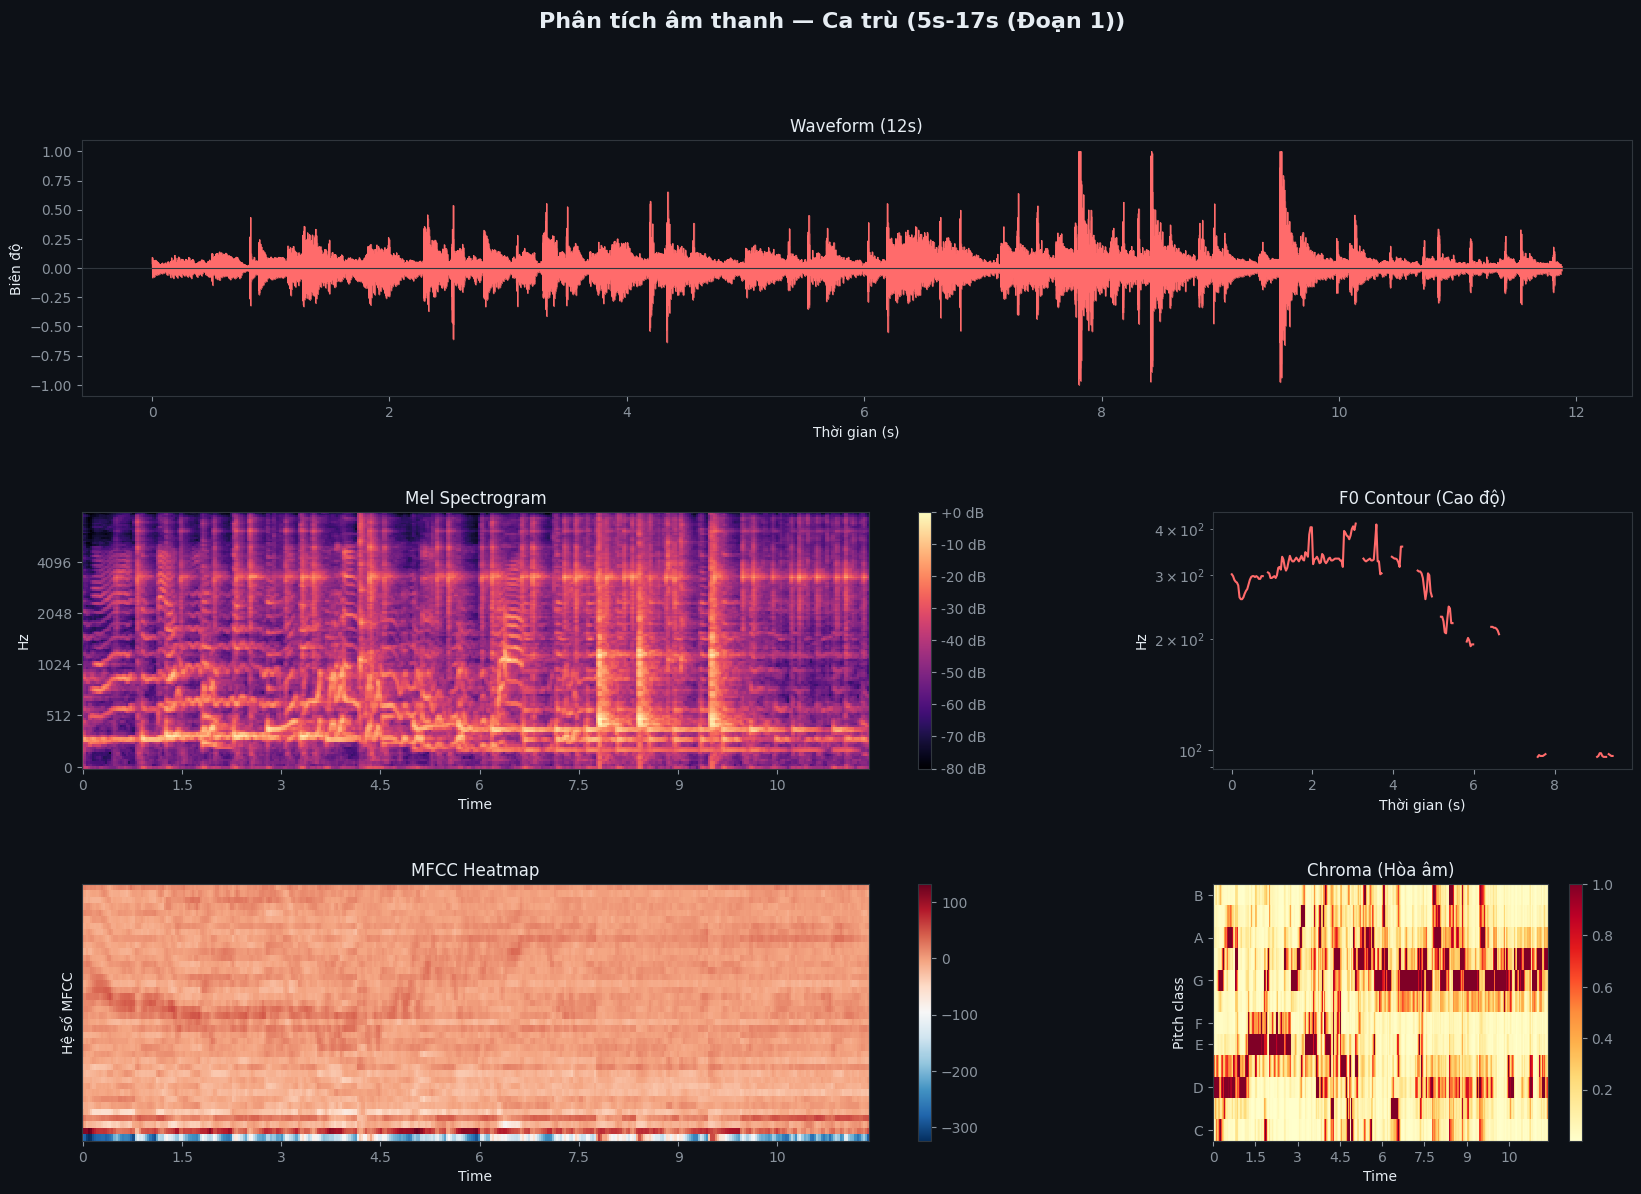


=== Chèo ===


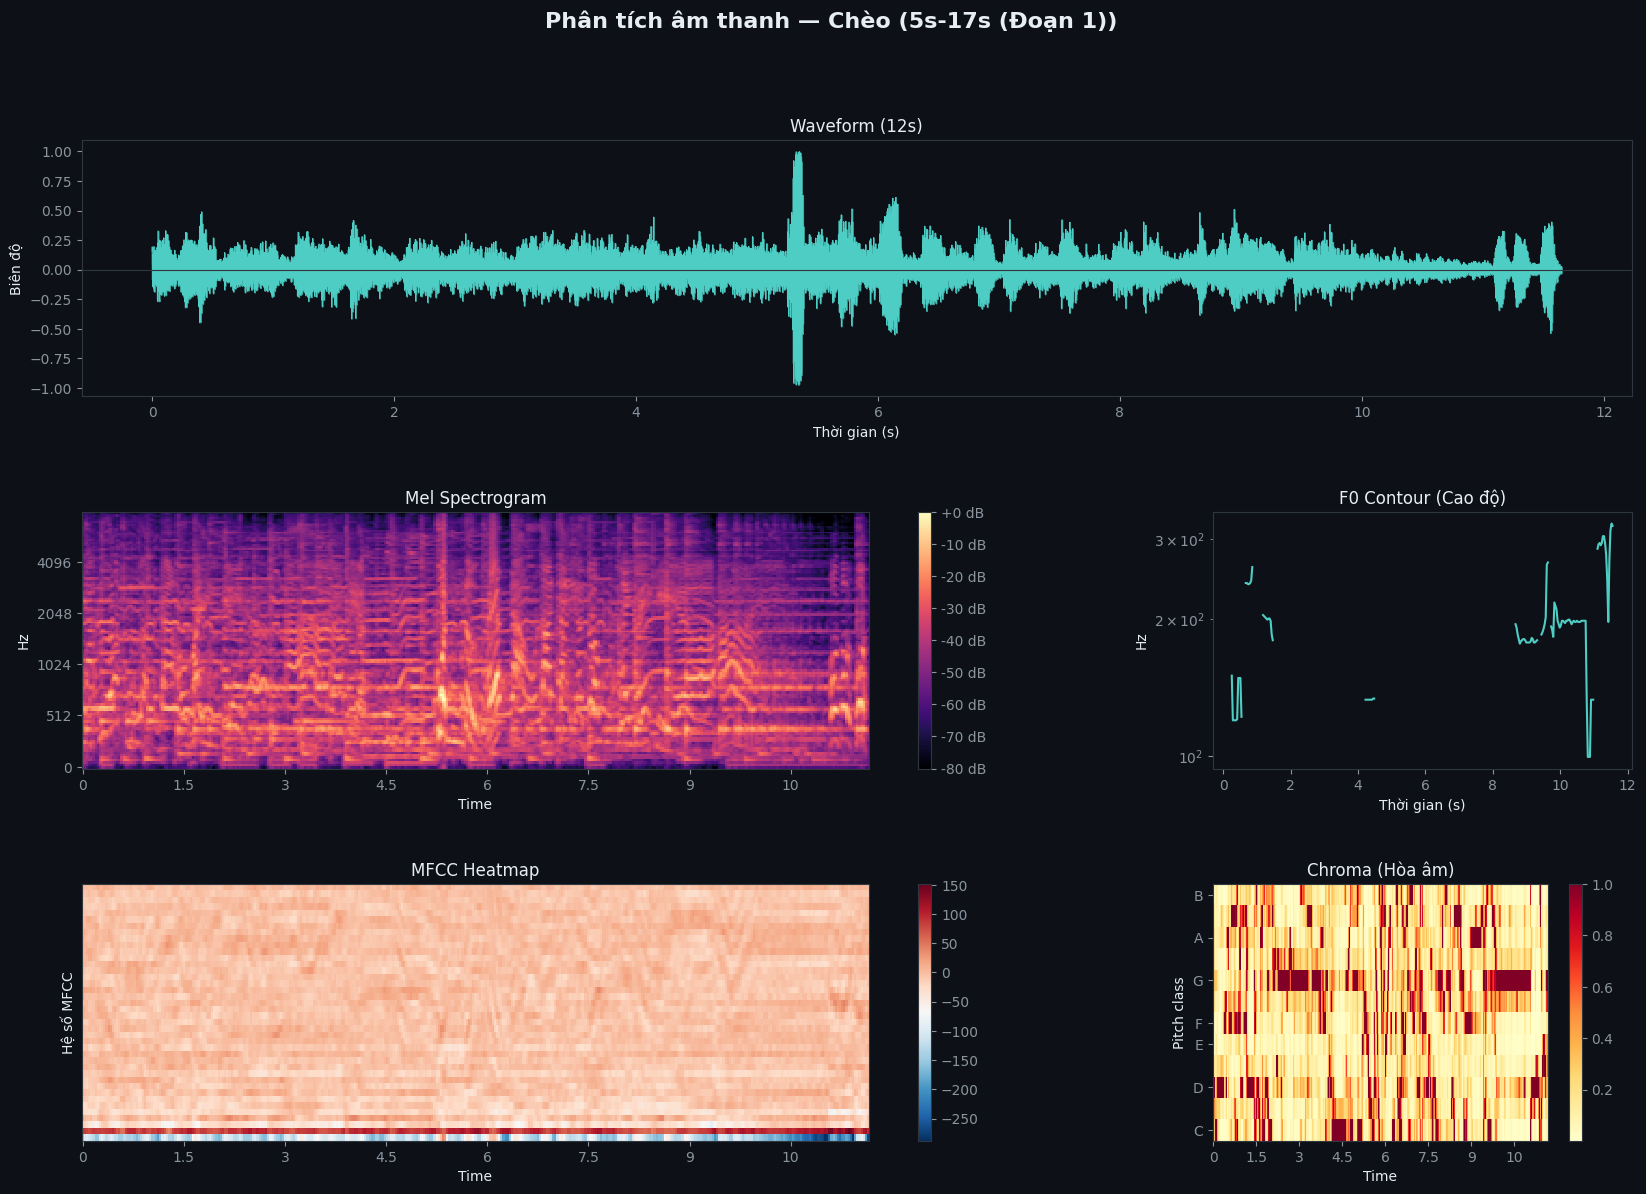


=== Chầu văn ===


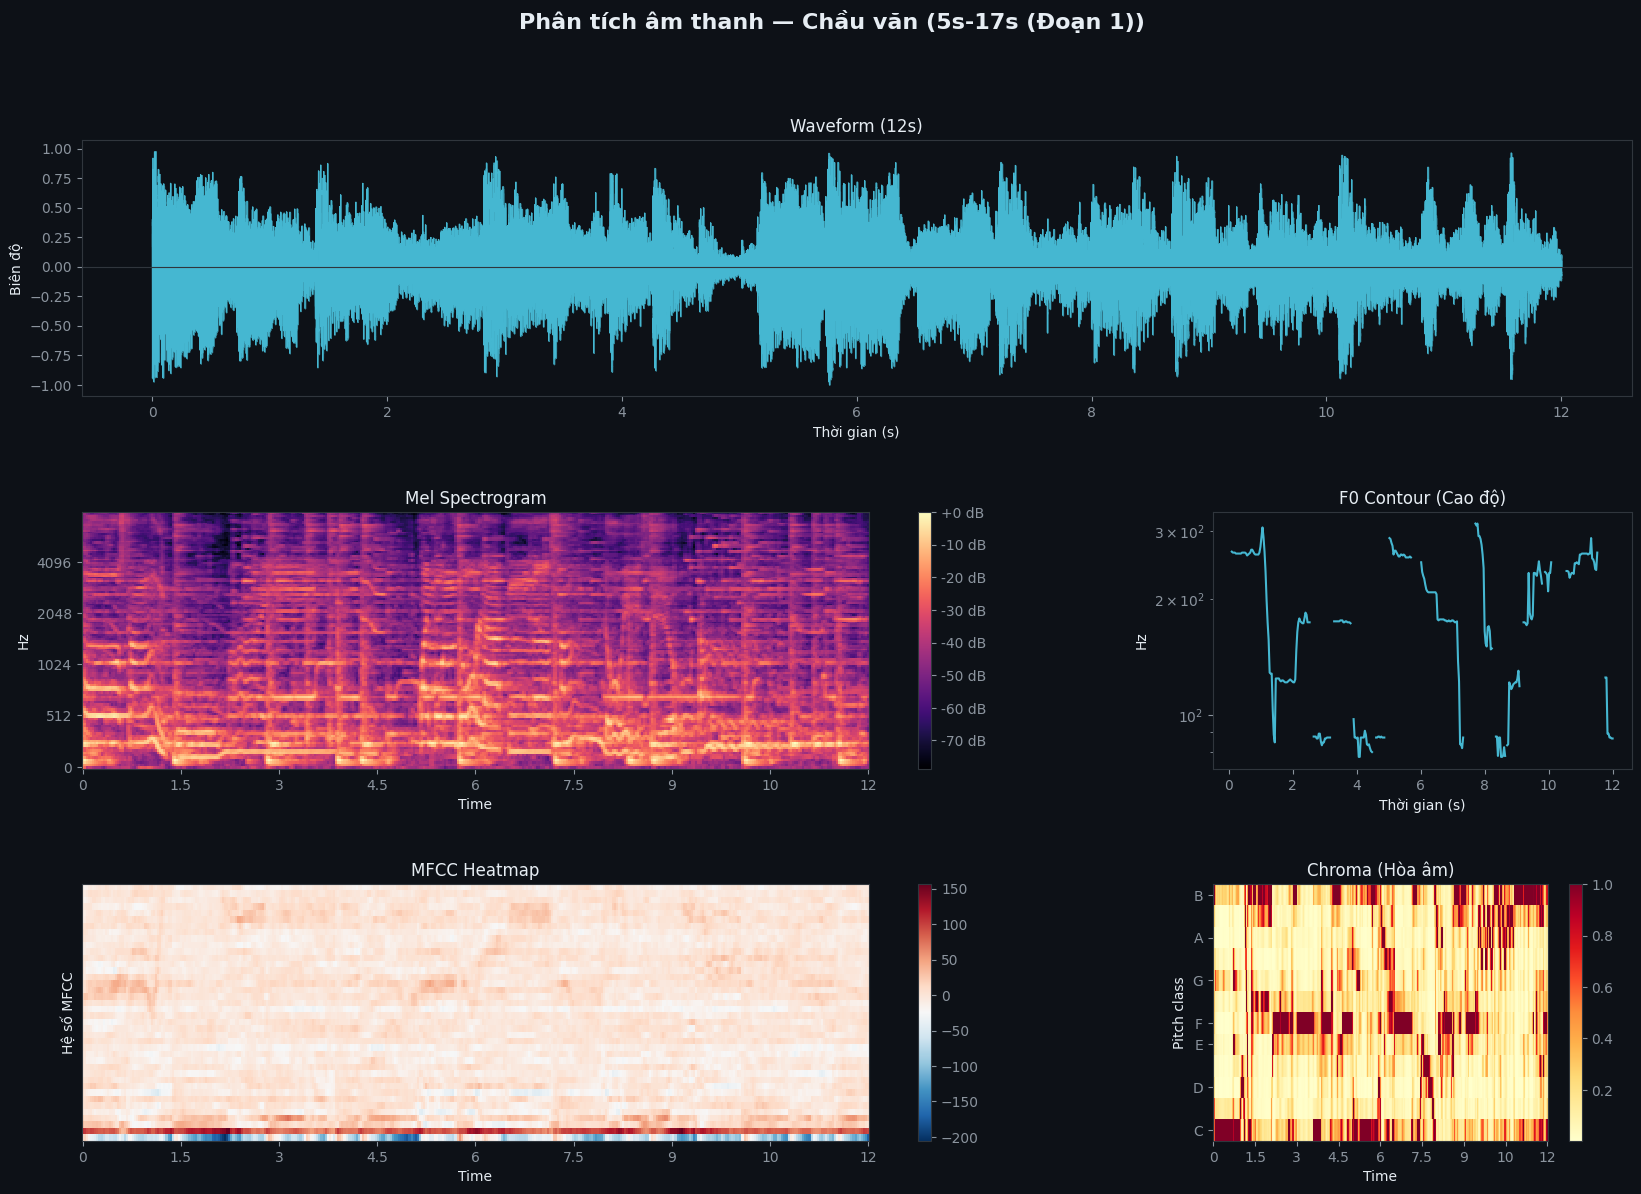


=== Cải lương ===


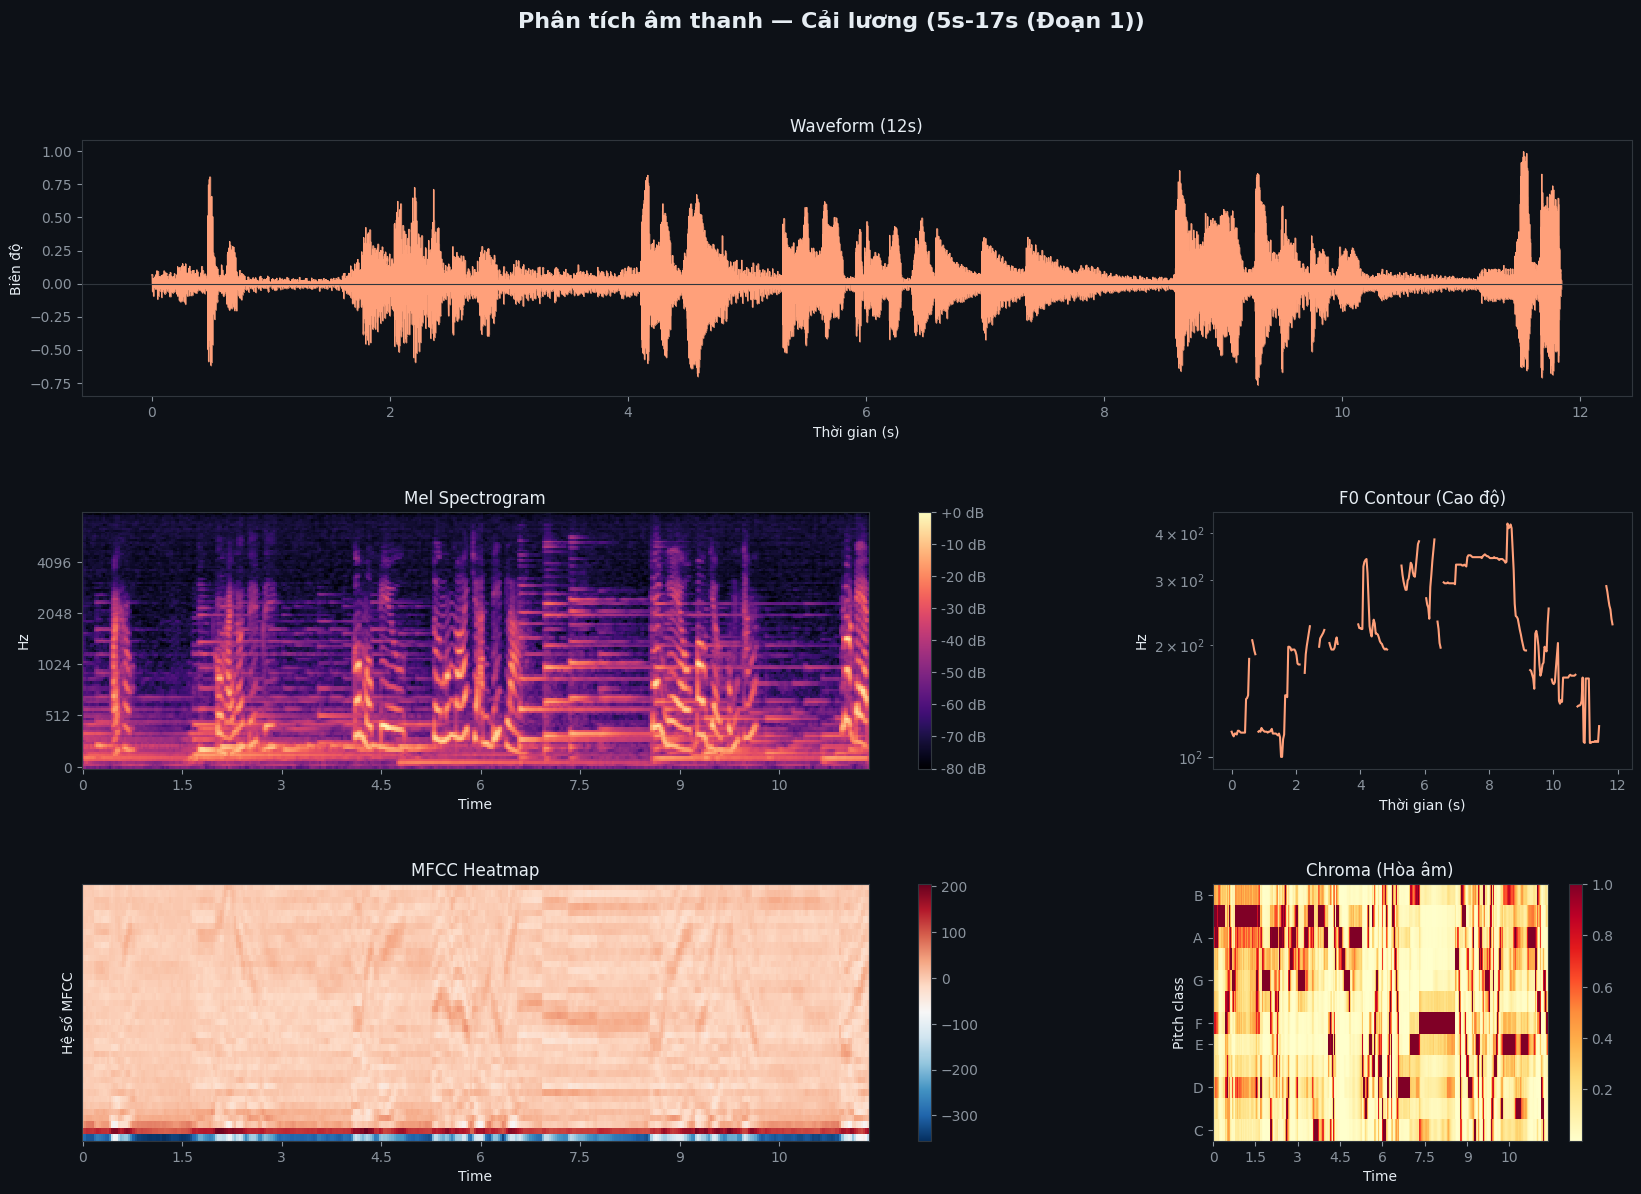


=== Hát xẩm ===


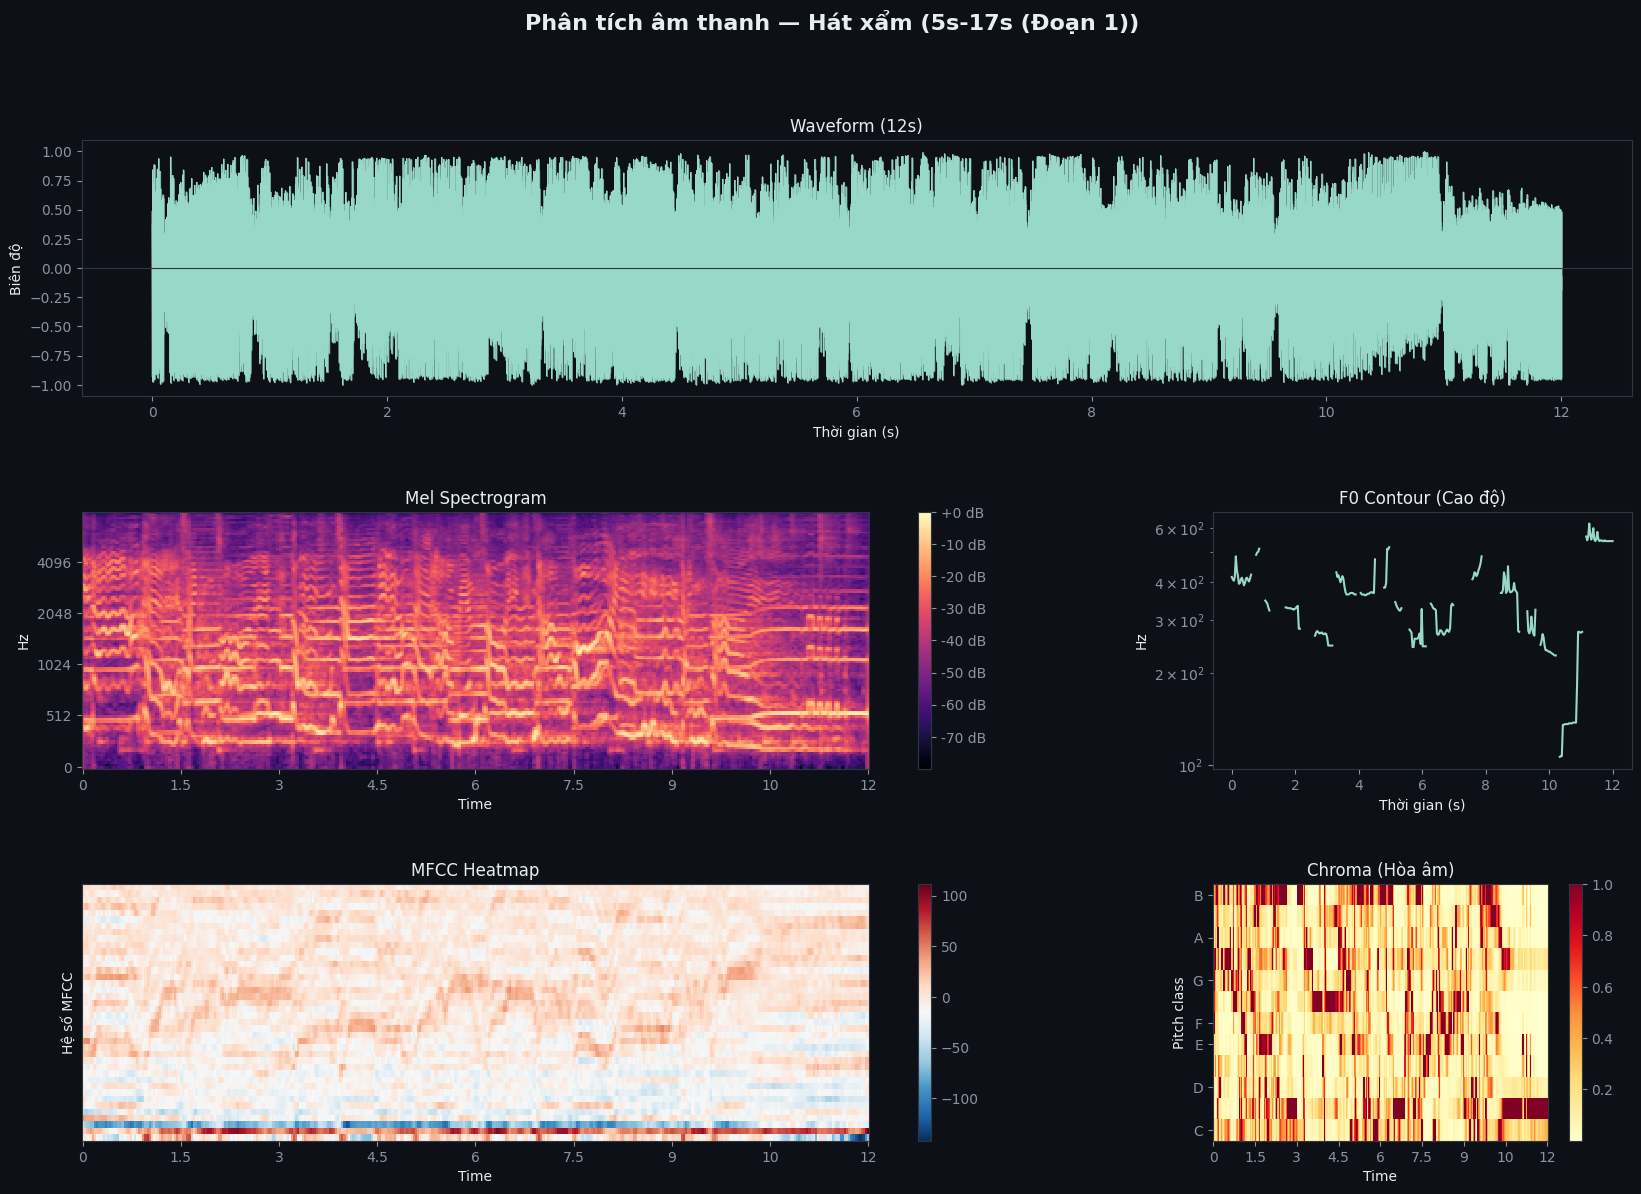


=== Quan họ ===


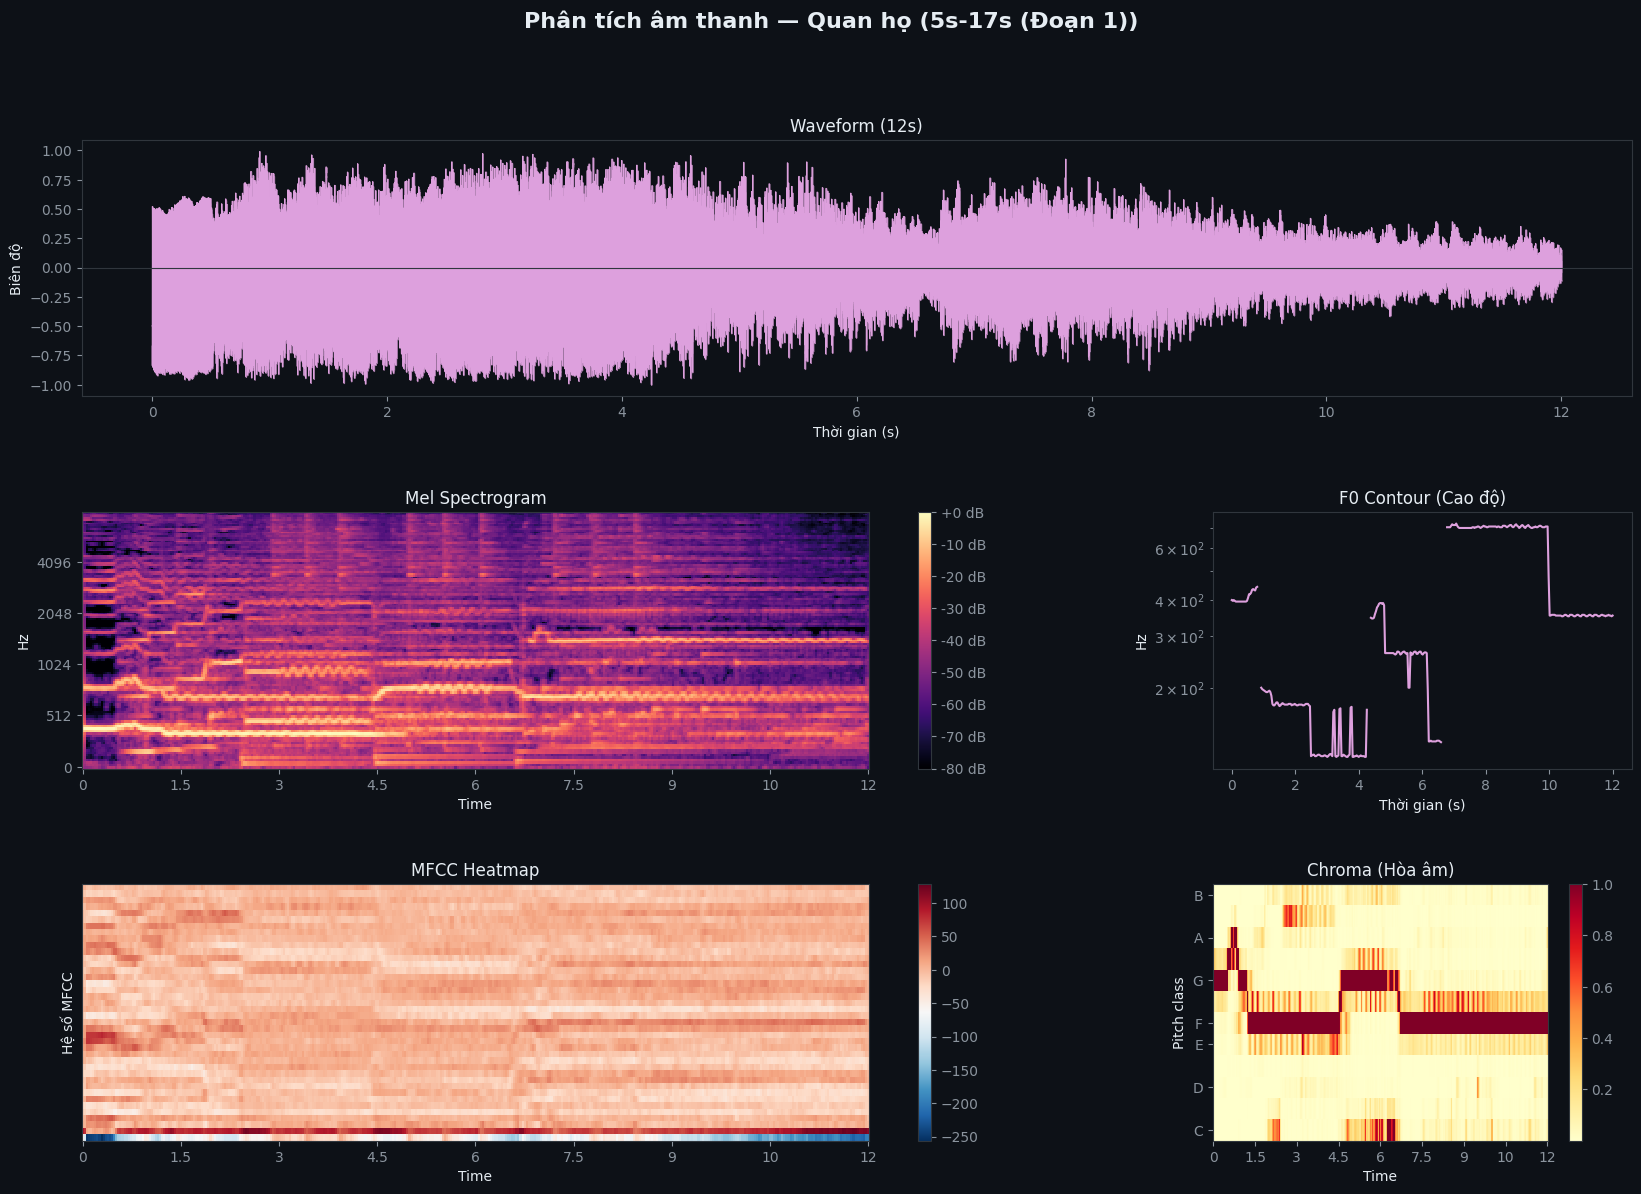

In [9]:
def visualize_sample(r, save=True):
    audio  = r.get('_audio');  sr   = r.get('_sr', SR_TARGET)
    f0     = r.get('_f0');     mfcc = r.get('_mfcc')
    mel    = r.get('_mel');    chroma = r.get('_chroma')
    label  = r.get('label','')
    color  = get_color(label)

    fig = plt.figure(figsize=(20, 13), facecolor='#0d1117')
    fig.suptitle(f'Phân tích âm thanh — {label} ({r.get("segment_time", "")})',
                 fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Waveform
    ax1 = fig.add_subplot(gs[0, :])
    if audio is not None:
        t = np.linspace(0, len(audio)/sr, len(audio))
        ax1.fill_between(t, audio, alpha=0.7, color=color)
        ax1.plot(t, audio, color=color, lw=0.5)
        ax1.axhline(0, color='#30363d', lw=0.8)
    ax1.set_title('Waveform (12s)'); ax1.set_xlabel('Thời gian (s)'); ax1.set_ylabel('Biên độ')

    # Mel Spectrogram
    ax2 = fig.add_subplot(gs[1, :2])
    if mel is not None:
        img = librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
        plt.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title('Mel Spectrogram')

    # F0 Contour
    ax3 = fig.add_subplot(gs[1, 2])
    if f0 is not None:
        ft = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=512)
        ax3.plot(ft, np.where(np.isnan(f0), np.nan, f0), color=color, lw=1.5)
    ax3.set_title('F0 Contour (Cao độ)')
    ax3.set_yscale('log'); ax3.set_xlabel('Thời gian (s)'); ax3.set_ylabel('Hz')

    # MFCC
    ax4 = fig.add_subplot(gs[2, :2])
    if mfcc is not None:
        img2 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax4, cmap='RdBu_r')
        plt.colorbar(img2, ax=ax4)
    ax4.set_title('MFCC Heatmap'); ax4.set_ylabel('Hệ số MFCC')

    # Chroma
    ax5 = fig.add_subplot(gs[2, 2])
    if chroma is not None:
        img3 = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=ax5, cmap='YlOrRd')
        plt.colorbar(img3, ax=ax5)
    ax5.set_title('Chroma (Hòa âm)')

    plt.tight_layout()
    if save:
        lbl_safe = str(label).replace(' ','_').replace('/','_')
        plt.savefig(f'./data/plots/viz_{lbl_safe}.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()

# Vẽ 1 mẫu đại diện cho mỗi thể loại (mẫu có mảng âm thanh)
seen = set()
for r in results:
    lbl = r.get('label','')
    if lbl not in seen and r.get('_audio') is not None:
        print(f'\n=== {lbl} ===')
        visualize_sample(r)
        seen.add(lbl)


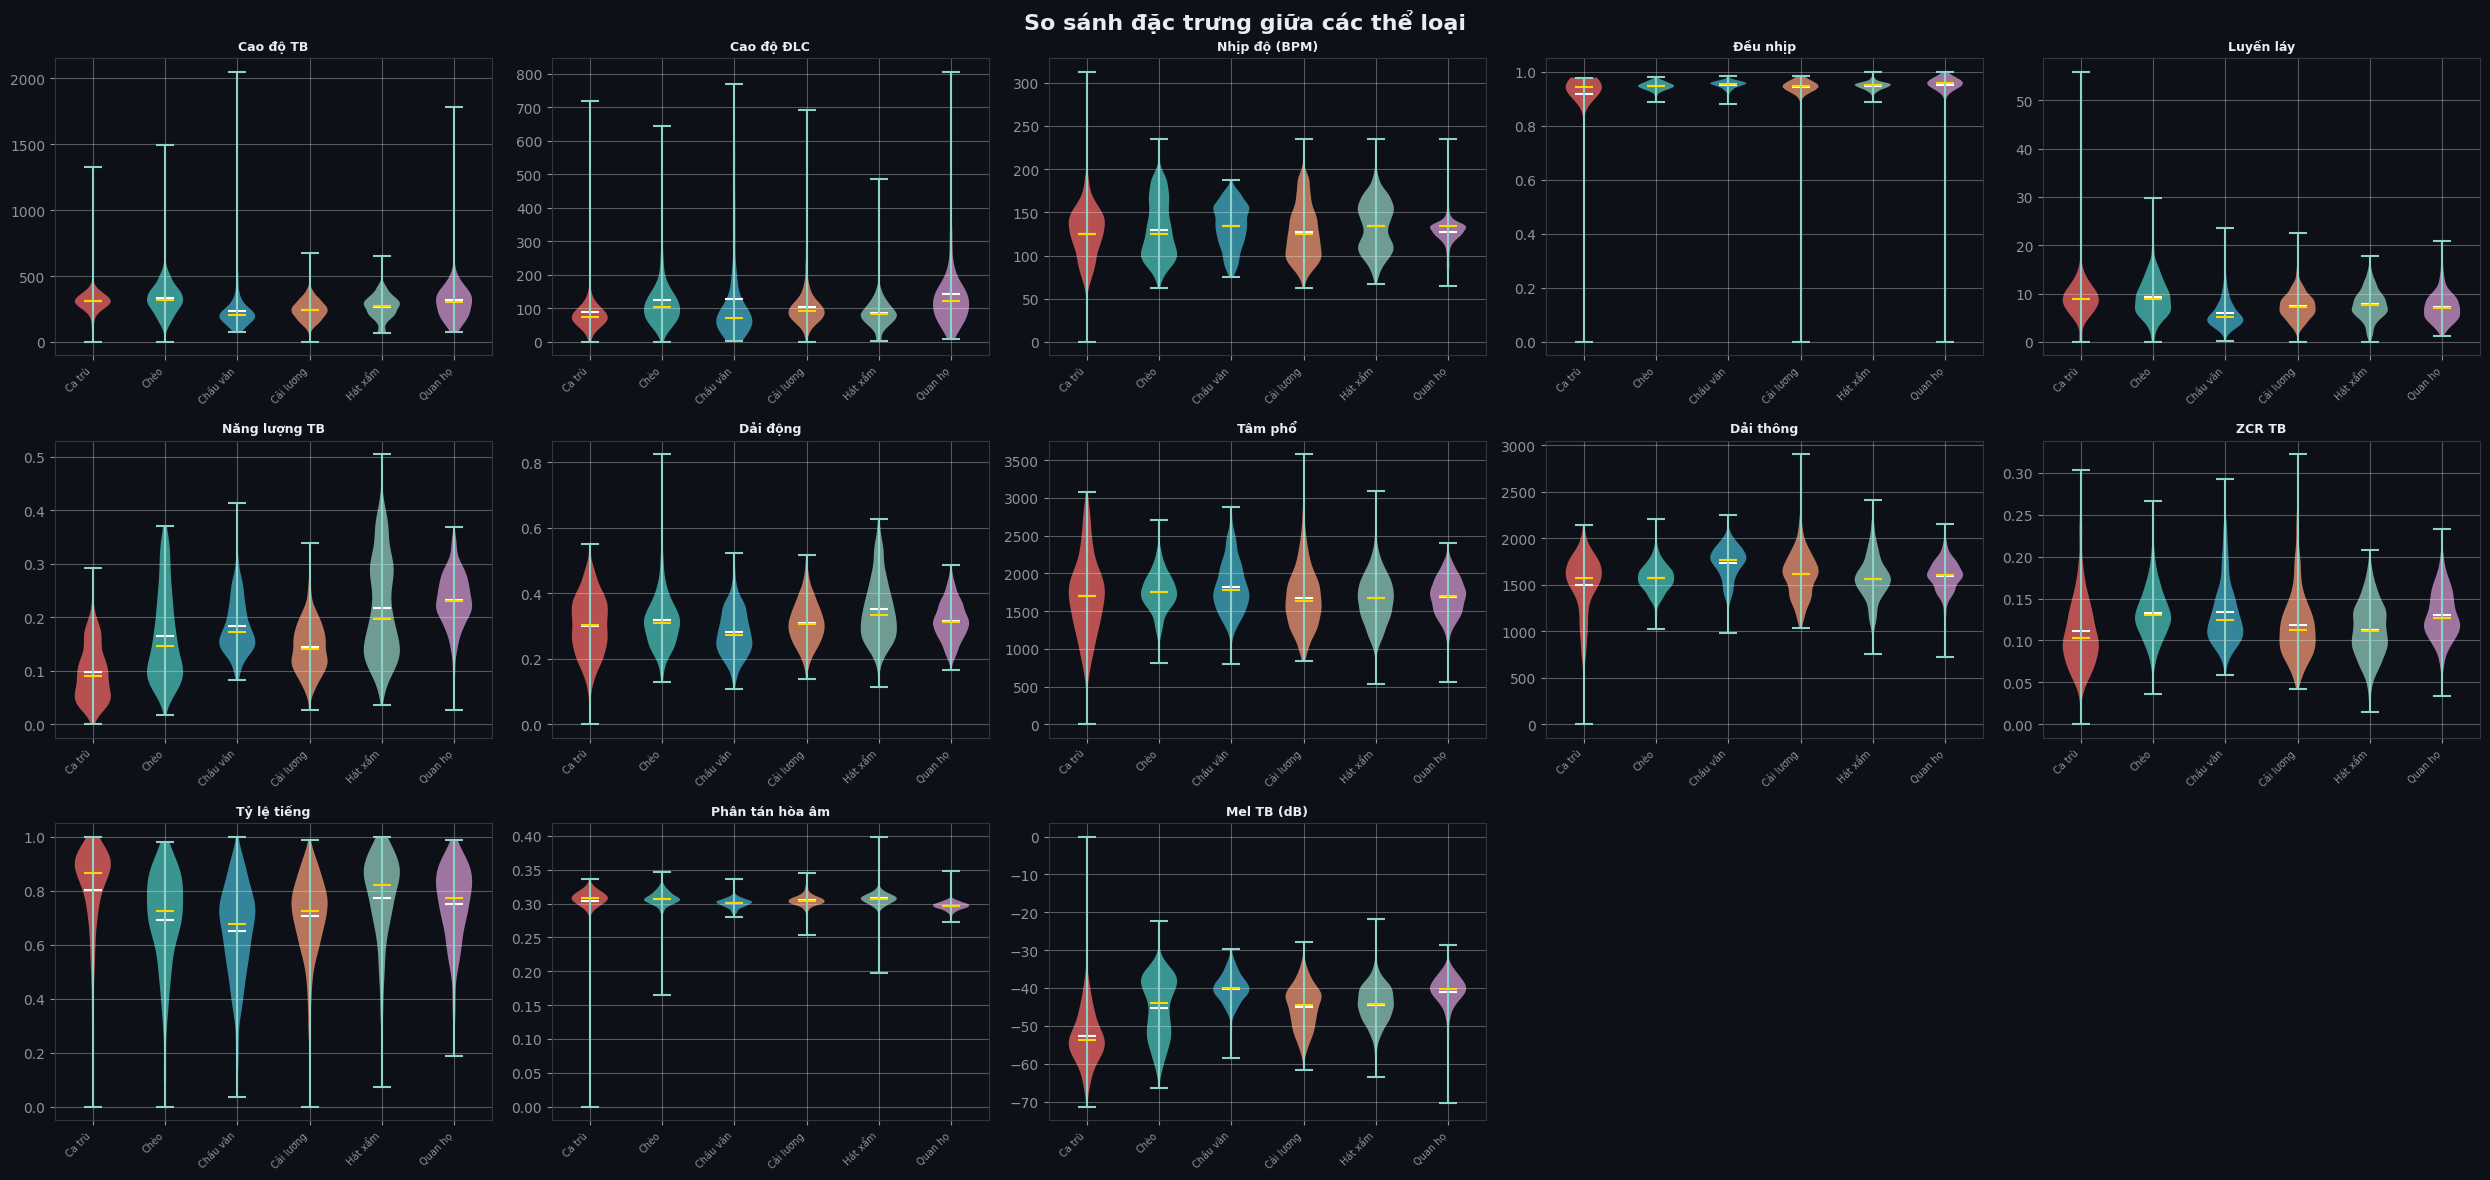

Saved: ./data/02_violin_comparison.png


In [10]:
# Violin plots so sánh đặc trưng
KEY_FEATS = ['pitch_mean','pitch_std','tempo','beat_regularity',
             'vibrato_extent','energy_mean','dynamic_range',
             'spectral_centroid_mean','spectral_bandwidth_mean',
             'zcr_mean','voiced_ratio','chroma_std_overall','mel_mean']

FEAT_LBL = {
    'pitch_mean':'Cao độ TB','pitch_std':'Cao độ ĐLC','tempo':'Nhịp độ (BPM)',
    'beat_regularity':'Đều nhịp','vibrato_extent':'Luyến láy',
    'energy_mean':'Năng lượng TB','dynamic_range':'Dải động',
    'spectral_centroid_mean':'Tâm phổ','spectral_bandwidth_mean':'Dải thông',
    'zcr_mean':'ZCR TB','voiced_ratio':'Tỷ lệ tiếng','chroma_std_overall':'Phân tán hòa âm',
    'mel_mean':'Mel TB (dB)',
}

# Lọc cột hợp lệ
valid_feats = [f for f in KEY_FEATS if f in df.columns and df[f].notna().sum() > 0]
df_num = df[valid_feats + ['label']].dropna()
genres = df_num['label'].unique()

n_feats = len(valid_feats)
cols = 5; rows = (n_feats + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(25, 4*rows), facecolor='#0d1117')
fig.suptitle('So sánh đặc trưng giữa các thể loại', fontsize=16, fontweight='bold',
             color='#e6edf3', y=0.98)

for i, feat in enumerate(valid_feats):
    ax = axes.flatten()[i]
    data_g  = [df_num[df_num['label']==g][feat].dropna().values for g in genres]
    data_g  = [d for d in data_g if len(d) > 0]
    cv      = [get_color(g) for g in genres if len(df_num[df_num['label']==g][feat].dropna()) > 0]
    parts = ax.violinplot(data_g, positions=range(len(data_g)), showmeans=True, showmedians=True)
    for pc, c in zip(parts['bodies'], cv):
        pc.set_facecolor(c); pc.set_alpha(0.7)
    parts['cmeans'].set_color('white')
    parts['cmedians'].set_color('#FFD700')
    ax.set_xticks(range(len(genres)))
    ax.set_xticklabels(genres, rotation=45, ha='right', fontsize=7)
    ax.set_title(FEAT_LBL.get(feat, feat), fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)

for ax in axes.flatten()[n_feats:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('./data/plots/02_violin_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/plots/02_violin_comparison.png')

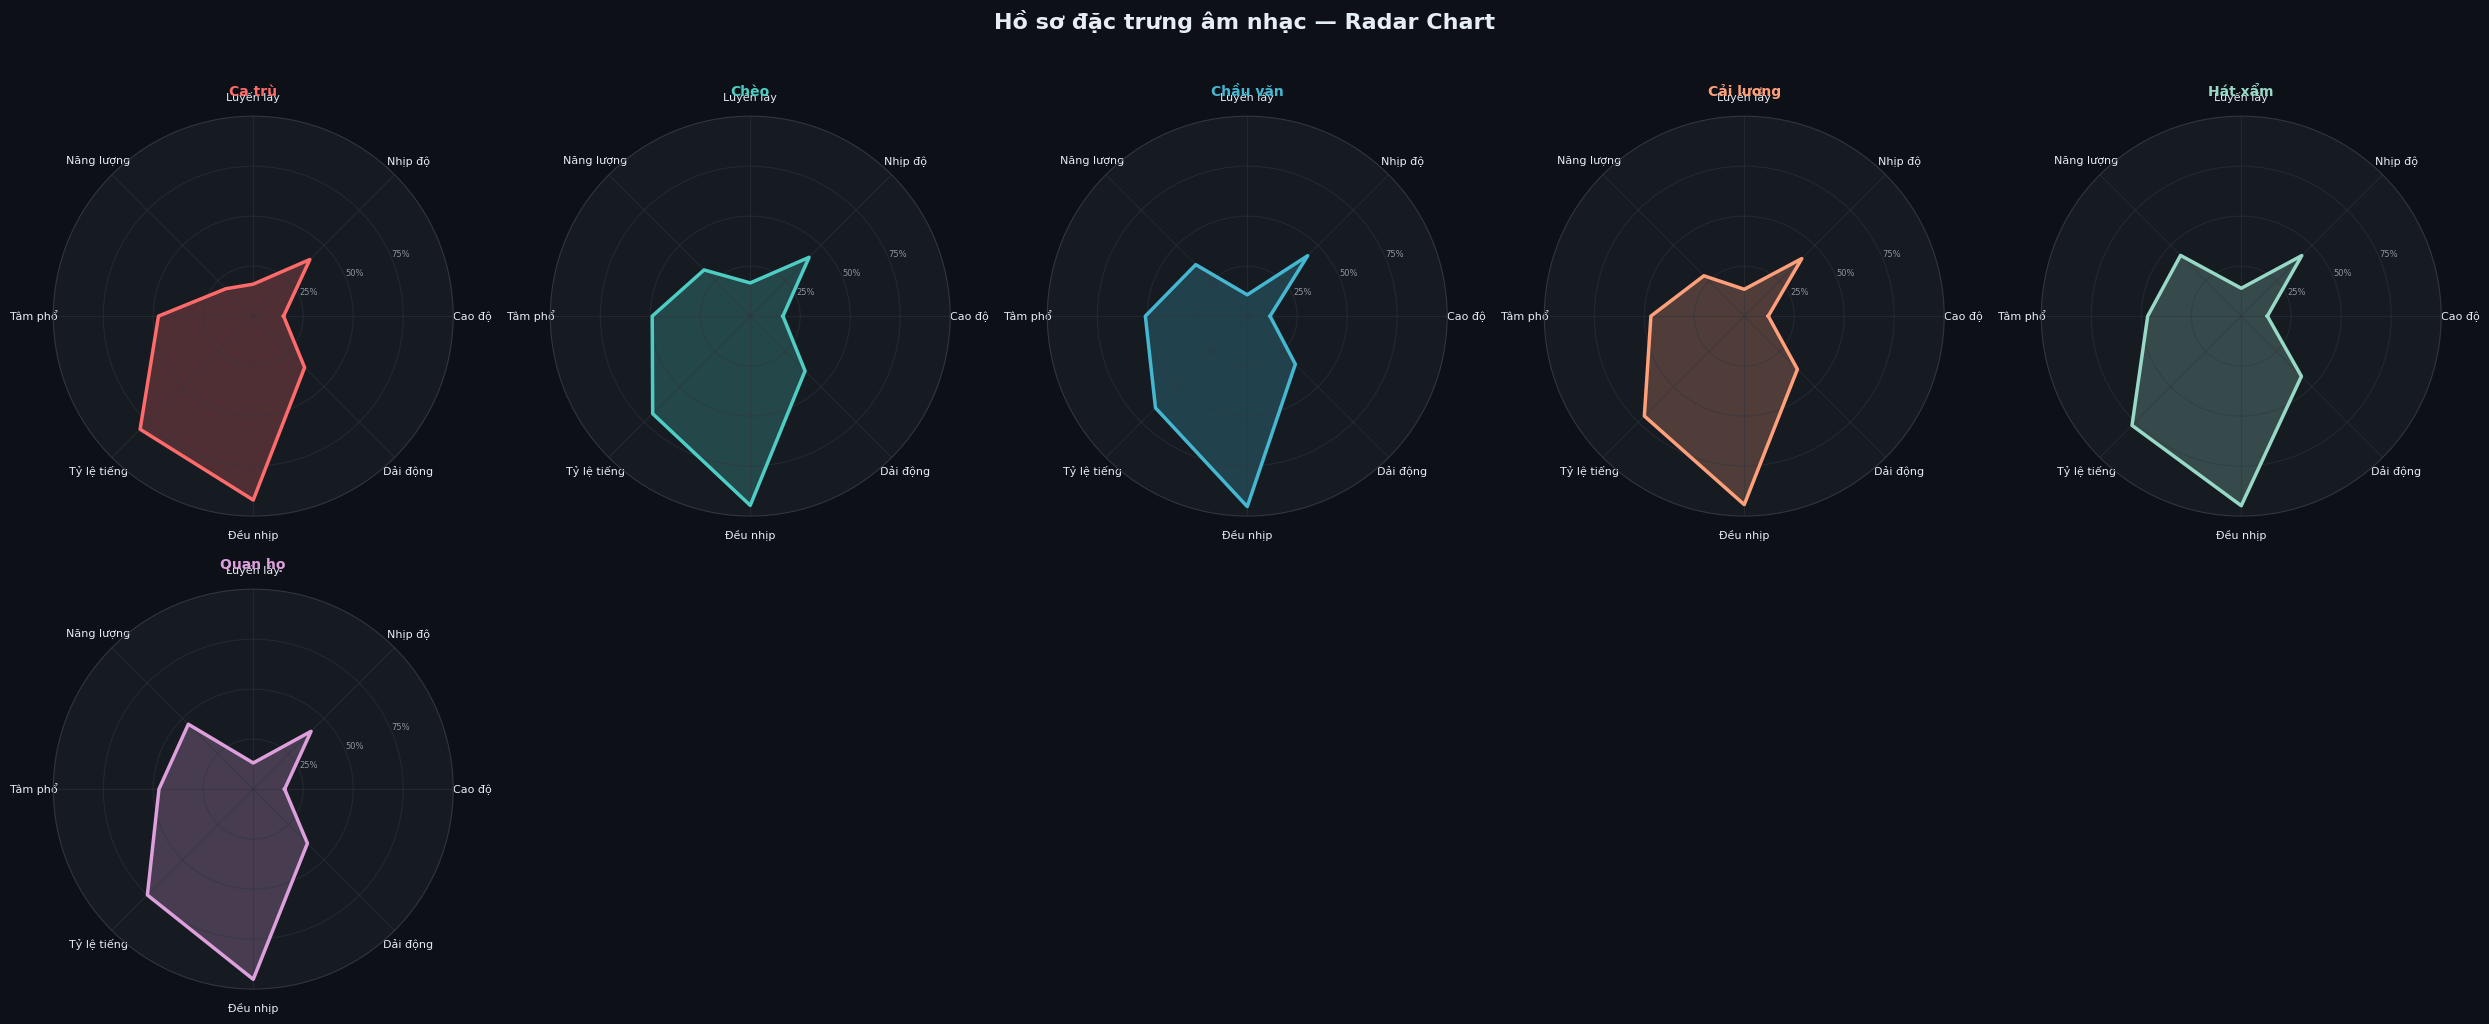

Saved: ./data/03_radar_chart.png


In [11]:
# Radar chart
radar_feats  = [f for f in ['pitch_mean','tempo','vibrato_extent','energy_mean',
                'spectral_centroid_mean','voiced_ratio','beat_regularity','dynamic_range']
                if f in df_num.columns]
radar_labels = ['Cao độ','Nhịp độ','Luyến láy','Năng lượng',
                'Tâm phổ','Tỷ lệ tiếng','Đều nhịp','Dải động'][:len(radar_feats)]

scaler_r = MinMaxScaler()
df_rr    = df_num[radar_feats].dropna()
df_rn    = pd.DataFrame(scaler_r.fit_transform(df_rr), columns=radar_feats, index=df_rr.index)
df_rn['label'] = df_num.loc[df_rr.index, 'label']
gmeans   = df_rn.groupby('label')[radar_feats].mean()

n_f    = len(radar_feats)
angles = np.linspace(0, 2*np.pi, n_f, endpoint=False).tolist() + [0]

n_genres = len(gmeans)
cols_r = min(5, n_genres); rows_r = (n_genres + cols_r - 1) // cols_r

fig, axes_r = plt.subplots(rows_r, cols_r, figsize=(5*cols_r, 5*rows_r),
                            subplot_kw=dict(polar=True), facecolor='#0d1117')
fig.suptitle('Hồ sơ đặc trưng âm nhạc — Radar Chart',
             fontsize=16, fontweight='bold', color='#e6edf3', y=1.02)

axes_flat = np.array(axes_r).flatten() if n_genres > 1 else [axes_r]
for idx, genre in enumerate(gmeans.index):
    ax  = axes_flat[idx]
    vals = gmeans.loc[genre].tolist() + [gmeans.loc[genre].tolist()[0]]
    c   = get_color(genre)
    ax.plot(angles[:len(vals)], vals, color=c, lw=2.5)
    ax.fill(angles[:len(vals)], vals, color=c, alpha=0.25)
    ax.set_xticks(angles[:n_f])
    ax.set_xticklabels(radar_labels, size=8, color='#e6edf3')
    ax.set_ylim(0, 1); ax.set_yticks([0.25,0.5,0.75])
    ax.set_yticklabels(['25%','50%','75%'], size=6, color='#8b949e')
    ax.grid(color='#30363d', alpha=0.5); ax.set_facecolor('#161b22')
    ax.set_title(genre, size=10, color=c, fontweight='bold', pad=15)

for ax in axes_flat[n_genres:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('./data/plots/03_radar_chart.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/plots/03_radar_chart.png')

Chạy t-SNE...
Xong!


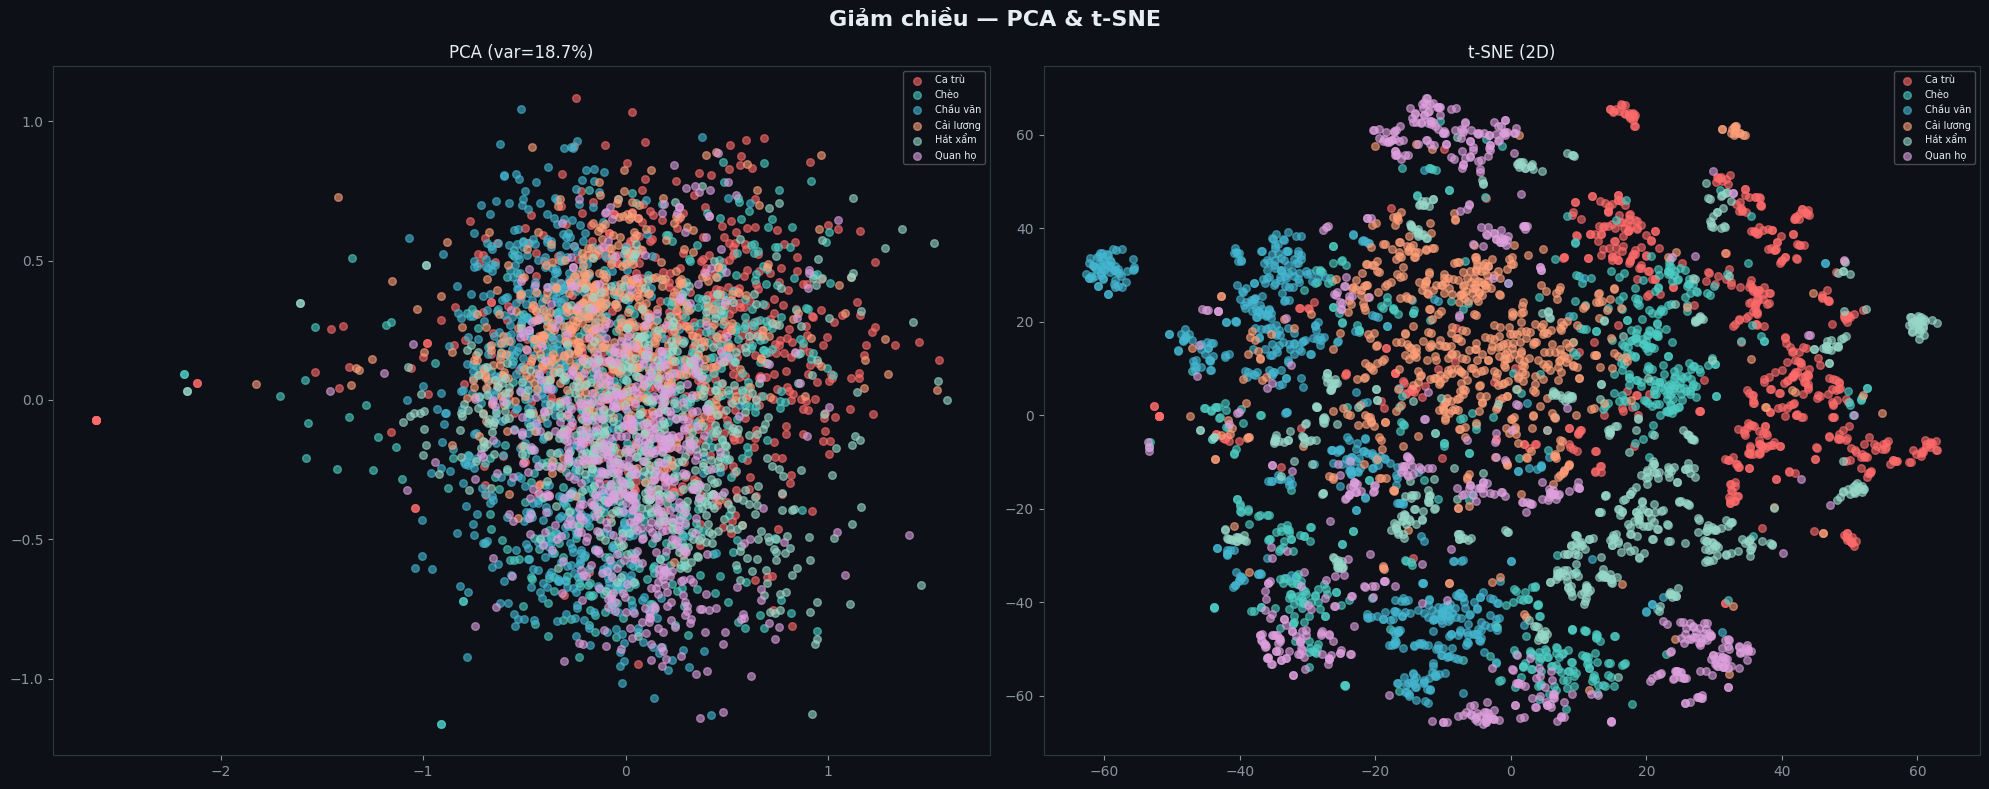

In [12]:
# PCA + t-SNE
feat_cols = [c for c in df.columns
             if c not in ['label','sample_idx'] and not c.startswith('_')
             and pd.api.types.is_float_dtype(df[c])]
X  = df[feat_cols].fillna(0).values
yl = df['label'].values

scaler = MinMaxScaler()  # Chuẩn hóa [0, 1] cho toàn bộ đặc trưng
Xs = scaler.fit_transform(X)

pca = PCA(n_components=min(50, X.shape[1]), random_state=42)
Xp  = pca.fit_transform(Xs)

print('Chạy t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Xt   = tsne.fit_transform(Xp[:, :20])
print('Xong!')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8), facecolor='#0d1117')
fig.suptitle('Giảm chiều — PCA & t-SNE', fontsize=16, fontweight='bold', color='#e6edf3')
for genre in np.unique(yl):
    m = yl==genre; c = get_color(genre)
    a1.scatter(Xp[m,0], Xp[m,1], c=c, label=genre, alpha=0.6, s=30)
    a2.scatter(Xt[m,0], Xt[m,1], c=c, label=genre, alpha=0.6, s=30)
a1.set_title(f'PCA (var={pca.explained_variance_ratio_[:2].sum()*100:.1f}%)')
a1.legend(fontsize=7, framealpha=0.3)
a2.set_title('t-SNE (2D)'); a2.legend(fontsize=7, framealpha=0.3)
plt.tight_layout()
plt.savefig('./data/plots/04_pca_tsne.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


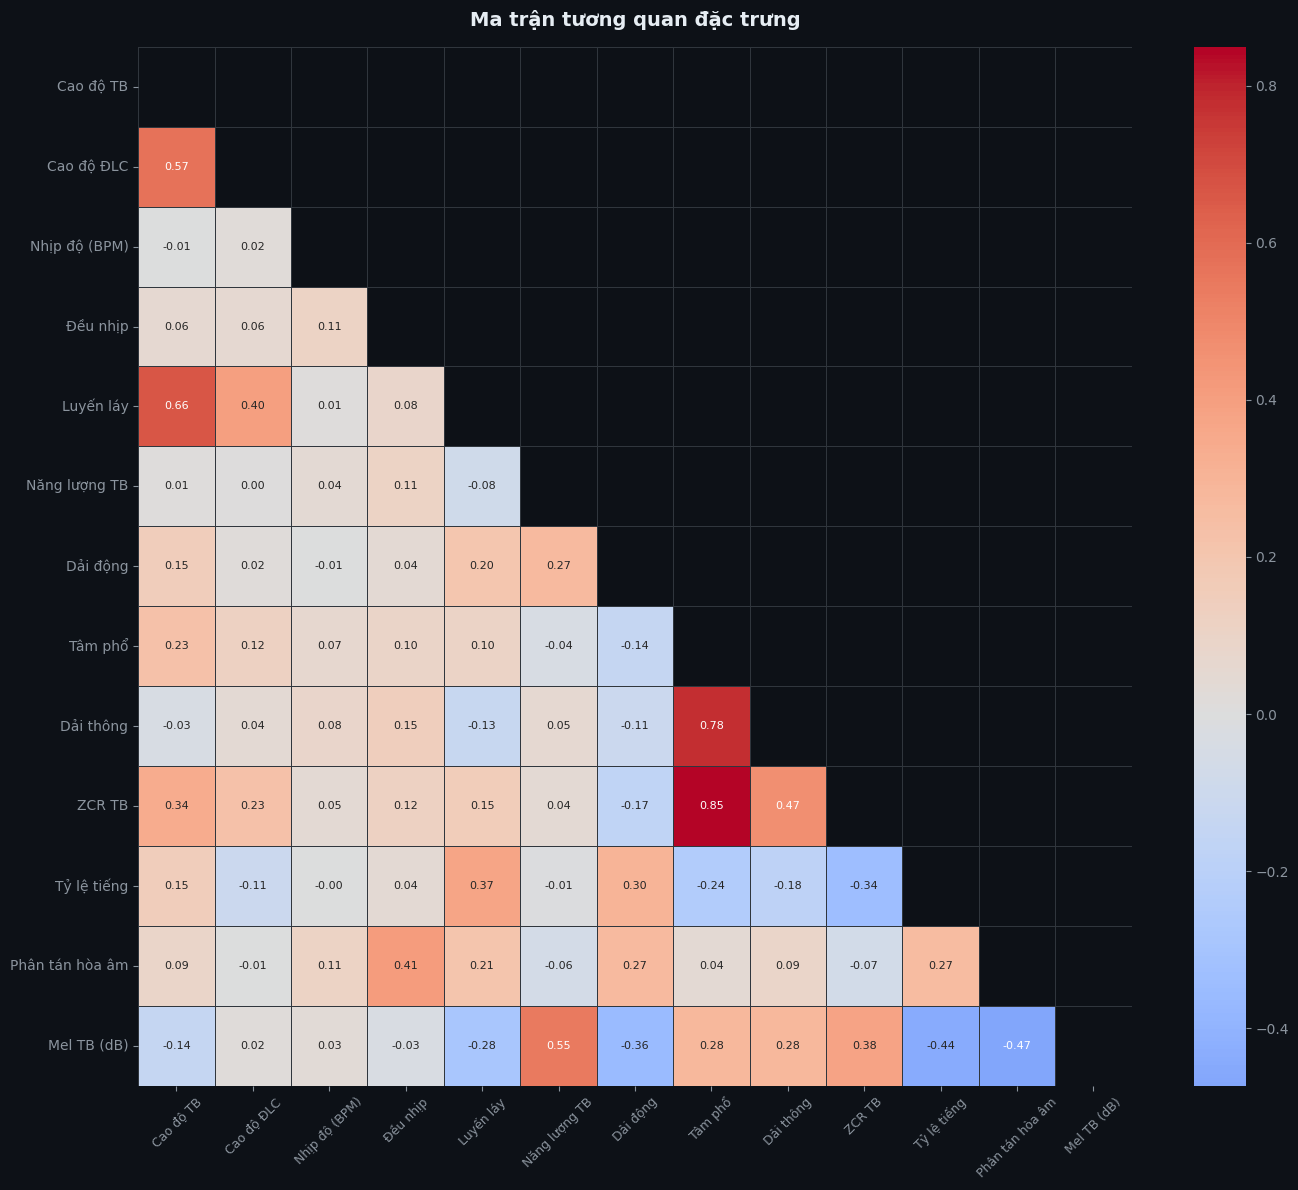

Saved: ./data/05_correlation.png


In [13]:
# Correlation heatmap
valid_for_corr = [f for f in KEY_FEATS if f in df.columns and df[f].notna().sum() > 10]
corr = df[valid_for_corr].corr()

fig, ax = plt.subplots(figsize=(14, 12), facecolor='#0d1117')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, linecolor='#30363d', annot_kws={'size':8},
            xticklabels=[FEAT_LBL.get(f,f) for f in valid_for_corr],
            yticklabels=[FEAT_LBL.get(f,f) for f in valid_for_corr])
ax.set_title('Ma trận tương quan đặc trưng', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig('./data/plots/05_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/plots/05_correlation.png')

## Bước 4: Phân Cụm Fuzzy

In [14]:
# Các trục đặc trưng để phân cụm và số mức độ mờ (Fuzzy Levels) dựa trên nghiên cứu chuyên ngành
FUZZY_AXES = {
    'Energy':   ['energy_mean', 'dynamic_range'],
    'Harmony':  [f'chroma_{n}_mean' for n in ['C','D','E','F','G','A','B']],
    'Pitch':    ['pitch_mean', 'pitch_range'],
    'Spectral': ['spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean'],
    'Tempo':    ['tempo'],
    'Timbre':   [f'mfcc_{i:02d}_mean' for i in range(1, 14)],
    'Vibrato':  ['vibrato_extent', 'vibrato_energy'],
}

# Cấu hình số mức độ mờ (Fuzzy Granularity) theo y văn chuyên ngành
FUZZY_LEVELS = {
    'Energy':   5,  # Rất yếu, Yếu, Vừa, Mạnh, Rất mạnh
    'Harmony':  3,  # Thấp, Trung bình, Cao
    'Pitch':    5,  # Rất trầm, Trầm, Trung, Cao, Rất cao
    'Spectral': 3,  # Thấp, Trung bình, Cao
    'Tempo':    3,  # Chậm, Vừa, Nhanh
    'Timbre':   5,  # Rất thấp, Thấp, Trung bình, Cao, Rất cao
    'Vibrato':  3,  # Ít luyến, Vừa, Nhiều luyến
}

feat_col_idx = {c: i for i, c in enumerate(feat_cols)}

def find_optimal_k(Xax, k_range=range(2, 8)):
    inertias, silhs, bics = [], [], []
    Xax = np.nan_to_num(Xax)
    n_pts = len(Xax)
    sample_sz = min(2000, n_pts)  # Lấy mẫu ngẫu nhiên 2000 điểm để tính silhouette nhanh trên tập lớn
    
    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xax)
        inertias.append(km.inertia_)
        silhs.append(silhouette_score(Xax, km.labels_, sample_size=sample_sz, random_state=42) if k > 1 else 0)
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(Xax)
        bics.append(gmm.bic(Xax))
    ks = list(k_range)
    d2 = np.diff(np.diff(np.array(inertias)))
    ek = ks[np.argmax(d2) + 1] if len(d2) > 0 else ks[0]
    sk = ks[np.argmax(silhs)]
    bk = ks[np.argmin(bics)]
    ok = Counter([ek, sk, bk]).most_common(1)[0][0]
    return dict(opt=ok, elbow=ek, silh=sk, bic=bk,
                inertias=inertias, silhs=silhs, bics=bics, ks=ks)

print('Khảo sát số cụm tối ưu toán học (để đối chiếu):')
opt_k = {}
for ax_name, ax_feats in FUZZY_AXES.items():
    vf   = [f for f in ax_feats if f in feat_col_idx]
    if not vf: print(f'  {ax_name}: bỏ qua (không có đặc trưng)'); continue
    cidx = [feat_col_idx[f] for f in vf]
    Xax  = np.nan_to_num(Xs[:, cidx])
    res  = find_optimal_k(Xax)
    opt_k[ax_name] = res
    print(f'  {ax_name:10s}: Elbow/BIC gợi ý k={res["opt"]} | Cấu hình nghiên cứu chọn k={FUZZY_LEVELS[ax_name]}')
print('\nThiết lập phân vùng mờ hoàn tất!')


Khảo sát số cụm tối ưu toán học (để đối chiếu):
  Energy    : Elbow/BIC gợi ý k=4 | Cấu hình nghiên cứu chọn k=5
  Harmony   : Elbow/BIC gợi ý k=3 | Cấu hình nghiên cứu chọn k=3
  Pitch     : Elbow/BIC gợi ý k=3 | Cấu hình nghiên cứu chọn k=5
  Spectral  : Elbow/BIC gợi ý k=3 | Cấu hình nghiên cứu chọn k=3
  Tempo     : Elbow/BIC gợi ý k=7 | Cấu hình nghiên cứu chọn k=3
  Timbre    : Elbow/BIC gợi ý k=4 | Cấu hình nghiên cứu chọn k=5
  Vibrato   : Elbow/BIC gợi ý k=4 | Cấu hình nghiên cứu chọn k=3

Thiết lập phân vùng mờ hoàn tất!


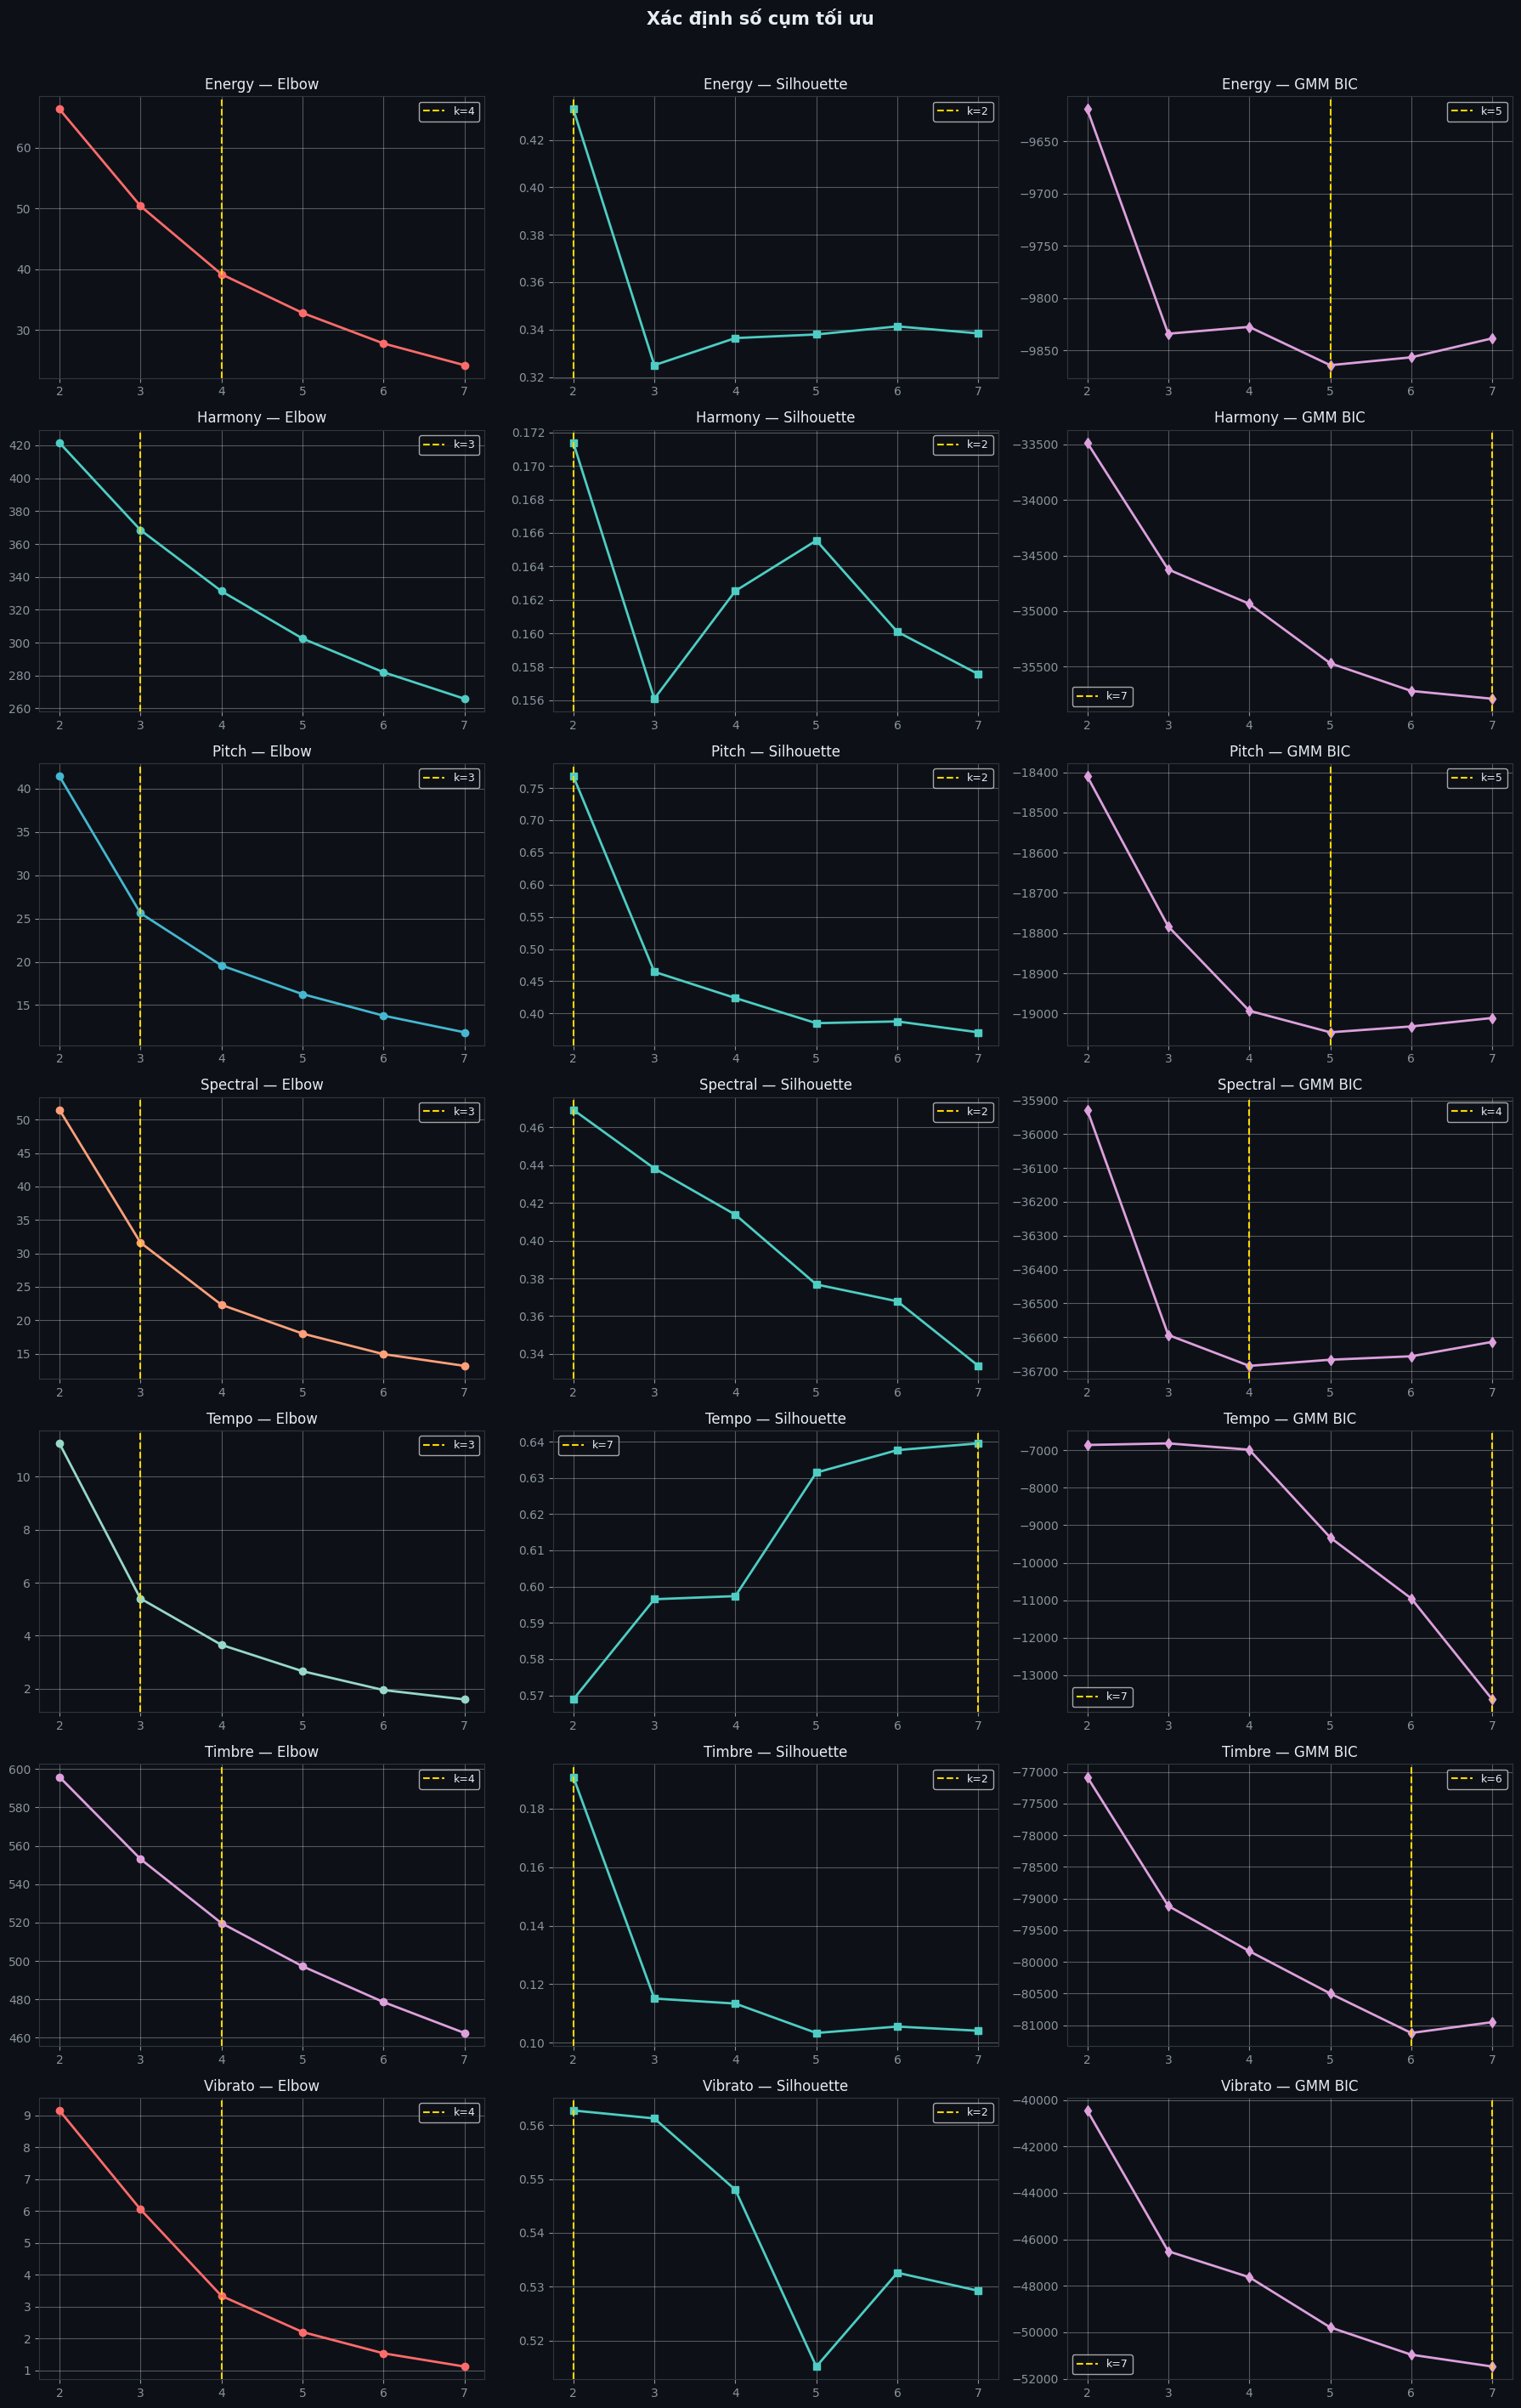

Saved: ./data/06_optimal_k.png


In [15]:
# Elbow / Silhouette / BIC plots
n_ax = len(opt_k)
fig, axg = plt.subplots(n_ax, 3, figsize=(18, 4*n_ax), facecolor='#0d1117')
fig.suptitle('Xác định số cụm tối ưu', fontsize=15, fontweight='bold', color='#e6edf3', y=1.01)
if n_ax == 1: axg = [axg]

COLS = list(GENRE_COLORS.values())
for ri, (ax_name, res) in enumerate(opt_k.items()):
    c = COLS[ri % len(COLS)]; ks = res['ks']; row = axg[ri]
    row[0].plot(ks,res['inertias'],'o-',color=c,lw=2,ms=6)
    row[0].axvline(res['elbow'],color='#FFD700',ls='--',label=f'k={res["elbow"]}')
    row[0].set_title(f'{ax_name} — Elbow'); row[0].legend(fontsize=9); row[0].grid(alpha=0.3)
    row[1].plot(ks,res['silhs'],'s-',color='#4ECDC4',lw=2,ms=6)
    row[1].axvline(res['silh'],color='#FFD700',ls='--',label=f'k={res["silh"]}')
    row[1].set_title(f'{ax_name} — Silhouette'); row[1].legend(fontsize=9); row[1].grid(alpha=0.3)
    row[2].plot(ks,res['bics'],'d-',color='#DDA0DD',lw=2,ms=6)
    row[2].axvline(res['bic'],color='#FFD700',ls='--',label=f'k={res["bic"]}')
    row[2].set_title(f'{ax_name} — GMM BIC'); row[2].legend(fontsize=9); row[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./data/plots/06_optimal_k.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/plots/06_optimal_k.png')

In [16]:
# Fuzzy C-Means với cấu hình mức độ mờ nghiên cứu (Tổng cộng 27 mức độ trên 7 trục)
LING = {
    2: ['Thấp','Cao'],
    3: ['Thấp','Trung bình','Cao'],
    4: ['Rất thấp','Thấp','Trung bình','Cao'],
    5: ['Rất thấp','Thấp','Trung bình','Cao','Rất cao'],
    6: ['Cực thấp','Rất thấp','Thấp','Trung bình','Cao','Rất cao'],
}
MUSIC_L = {
    'Energy':   {5: ['Rất yếu', 'Yếu', 'Vừa', 'Mạnh', 'Rất mạnh']},
    'Harmony':  {3: ['Thấp', 'Trung bình', 'Cao']},
    'Pitch':    {5: ['Rất trầm', 'Trầm', 'Trung', 'Cao', 'Rất cao']},
    'Spectral': {3: ['Thấp', 'Trung bình', 'Cao']},
    'Tempo':    {3: ['Chậm', 'Vừa', 'Nhanh']},
    'Timbre':   {5: ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']},
    'Vibrato':  {3: ['Ít luyến', 'Vừa', 'Nhiều luyến']},
}

fcm_res = {}
crisp_dict = {'sample_idx': df['sample_idx'], 'label': df['label']}
continuous_dict = {'sample_idx': df['sample_idx'], 'label': df['label']}
total_continuous_cols = 0

print('Chạy Fuzzy C-Means theo cấu hình phân mức nghiên cứu...')
for ax_name, k in FUZZY_LEVELS.items():
    ax_feats = FUZZY_AXES[ax_name]
    vf = [f for f in ax_feats if f in feat_col_idx]
    cidx = [feat_col_idx[f] for f in vf]
    Xax  = np.nan_to_num(Xs[:, cidx]).T   # (features, samples)
    try:
        cntr, u, _, _, _, _, fpc = cmeans(Xax, c=k, m=2.0, error=0.005, maxiter=1000, seed=42)
        sorted_idx = np.argsort(cntr.mean(axis=1))
        names = MUSIC_L.get(ax_name, {}).get(k, LING.get(k, [f'Mức {i+1}' for i in range(k)]))
        cnames = {sorted_idx[i]: names[i] for i in range(k)}
        
        # 1. Nhãn chữ cứng (Crisp label)
        hard_idx = np.argmax(u, axis=0)
        crisp_dict[ax_name] = [cnames[idx] for idx in hard_idx]
        
        # 2. Mức độ mờ liên tục [0, 1]
        for i in range(k):
            cluster_orig_idx = sorted_idx[i]
            level_name = names[i]
            col_name = f"{ax_name}_{level_name}".replace(' ', '_')
            continuous_dict[col_name] = np.round(u[cluster_orig_idx, :], 4)
            total_continuous_cols += 1
            
        fcm_res[ax_name] = dict(k=k, centers=cntr, membership=u,
                                 hard=hard_idx, names=cnames, sorted_idx=sorted_idx, fpc=fpc, feats=vf)
        print(f'  {ax_name:10s} k={k} FPC={fpc:.3f} → {names}')
    except Exception as e:
        print(f'  {ax_name}: Lỗi FCM: {e}')

# Tạo và lưu 2 bảng dữ liệu mới
df_crisp = pd.DataFrame(crisp_dict)
df_continuous = pd.DataFrame(continuous_dict)

df_crisp.to_csv('./data/datasets/features_fuzzy_crisp.csv', index=False)
df_continuous.to_csv('./data/datasets/features_fuzzy_continuous.csv', index=False)

print(f'\nĐã tạo thành công 2 bảng dữ liệu mờ:')
print(f'  1. features_fuzzy_crisp.csv:      {df_crisp.shape[0]} mẫu × {df_crisp.shape[1]} cột (7 cột nhãn chữ + sample_idx + label)')
print(f'  2. features_fuzzy_continuous.csv: {df_continuous.shape[0]} mẫu × {df_continuous.shape[1]} cột ({total_continuous_cols} cột mức độ mờ [0, 1] + sample_idx + label)')


Chạy Fuzzy C-Means theo cấu hình phân mức nghiên cứu...
  Energy     k=5 FPC=0.508 → ['Rất yếu', 'Yếu', 'Vừa', 'Mạnh', 'Rất mạnh']
  Harmony    k=3 FPC=0.333 → ['Thấp', 'Trung bình', 'Cao']
  Pitch      k=5 FPC=0.630 → ['Rất trầm', 'Trầm', 'Trung', 'Cao', 'Rất cao']
  Spectral   k=3 FPC=0.700 → ['Thấp', 'Trung bình', 'Cao']
  Tempo      k=3 FPC=0.788 → ['Chậm', 'Vừa', 'Nhanh']
  Timbre     k=5 FPC=0.210 → ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']
  Vibrato    k=3 FPC=0.774 → ['Ít luyến', 'Vừa', 'Nhiều luyến']

Đã tạo thành công 2 bảng dữ liệu mờ:
  1. features_fuzzy_crisp.csv:      3600 mẫu × 9 cột (7 cột nhãn chữ + sample_idx + label)
  2. features_fuzzy_continuous.csv: 3600 mẫu × 29 cột (27 cột mức độ mờ [0, 1] + sample_idx + label)


In [17]:
# GMM với cấu hình mức độ mờ nghiên cứu
gmm_res = {}
print('Chạy Gaussian Mixture Models (GMM)...')
for ax_name, k in FUZZY_LEVELS.items():
    ax_feats = FUZZY_AXES[ax_name]
    vf = [f for f in ax_feats if f in feat_col_idx]
    cidx = [feat_col_idx[f] for f in vf]
    Xax  = np.nan_to_num(Xs[:, cidx])
    try:
        gmm    = GaussianMixture(n_components=k, covariance_type='full',
                                  random_state=42, n_init=10).fit(Xax)
        probs  = gmm.predict_proba(Xax)
        si     = np.argsort(gmm.means_.mean(axis=1))
        names  = MUSIC_L.get(ax_name, {}).get(k, LING.get(k, [f'Mức {i+1}' for i in range(k)]))
        cnames = {si[i]: names[i] for i in range(k)}
        gmm_res[ax_name] = dict(model=gmm, k=k, probs=probs,
                                 hard=gmm.predict(Xax), names=cnames, sorted_idx=si, bic=gmm.bic(Xax), feats=vf)
        print(f'  {ax_name:10s} k={k} BIC={gmm.bic(Xax):.1f} → {names}')
    except Exception as e:
        print(f'  {ax_name}: Lỗi GMM: {e}')
print('\nGMM xong!')


Chạy Gaussian Mixture Models (GMM)...
  Energy     k=5 BIC=-9864.2 → ['Rất yếu', 'Yếu', 'Vừa', 'Mạnh', 'Rất mạnh']
  Harmony    k=3 BIC=-34626.2 → ['Thấp', 'Trung bình', 'Cao']
  Pitch      k=5 BIC=-19047.0 → ['Rất trầm', 'Trầm', 'Trung', 'Cao', 'Rất cao']
  Spectral   k=3 BIC=-36593.3 → ['Thấp', 'Trung bình', 'Cao']
  Tempo      k=3 BIC=-6816.3 → ['Chậm', 'Vừa', 'Nhanh']
  Timbre     k=5 BIC=-80500.6 → ['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao']
  Vibrato    k=3 BIC=-46512.7 → ['Ít luyến', 'Vừa', 'Nhiều luyến']

GMM xong!


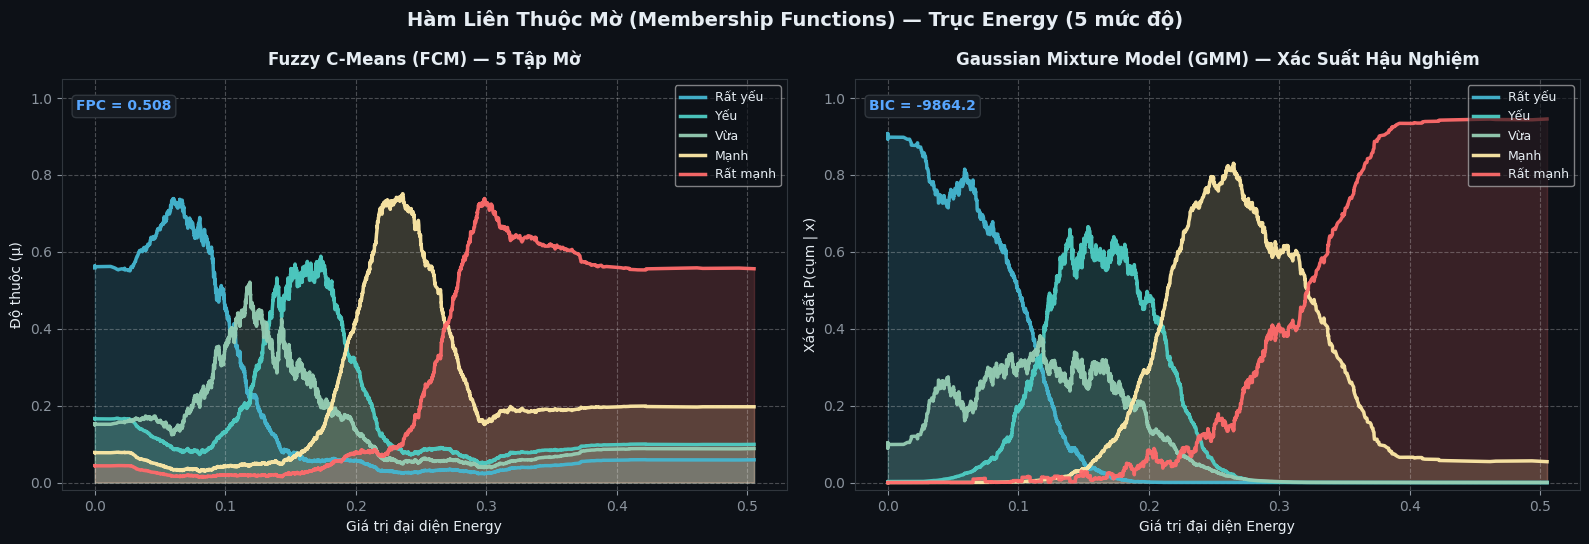

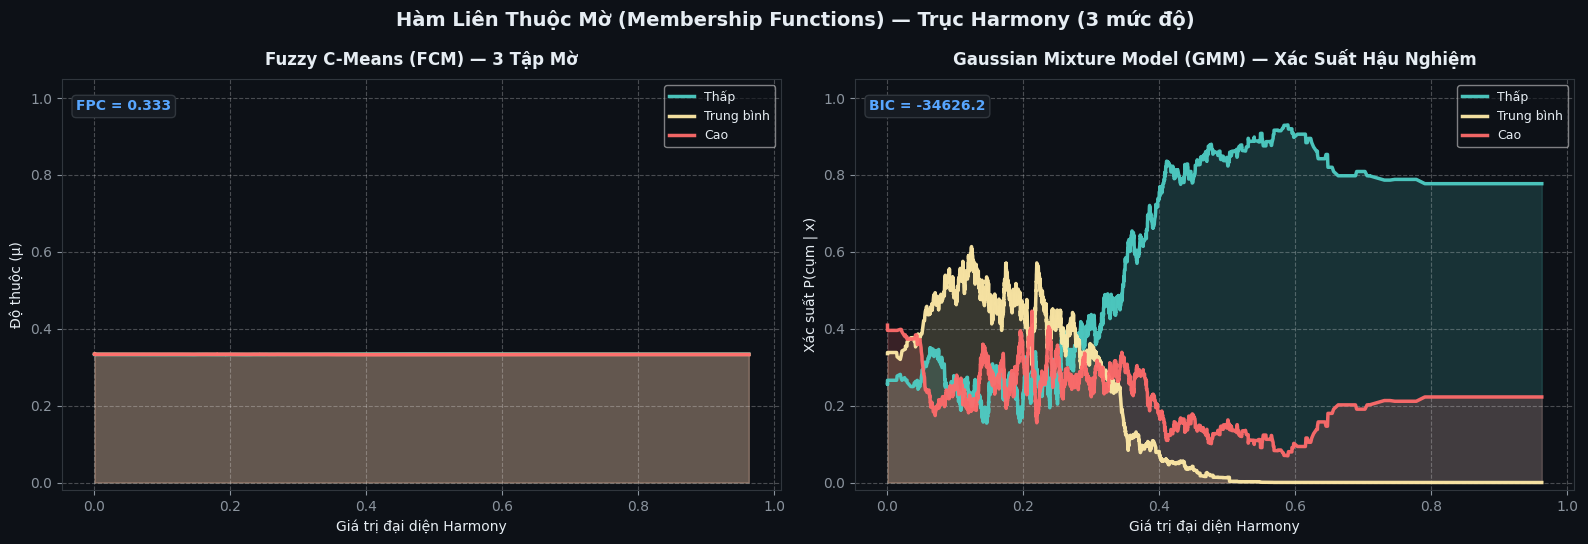

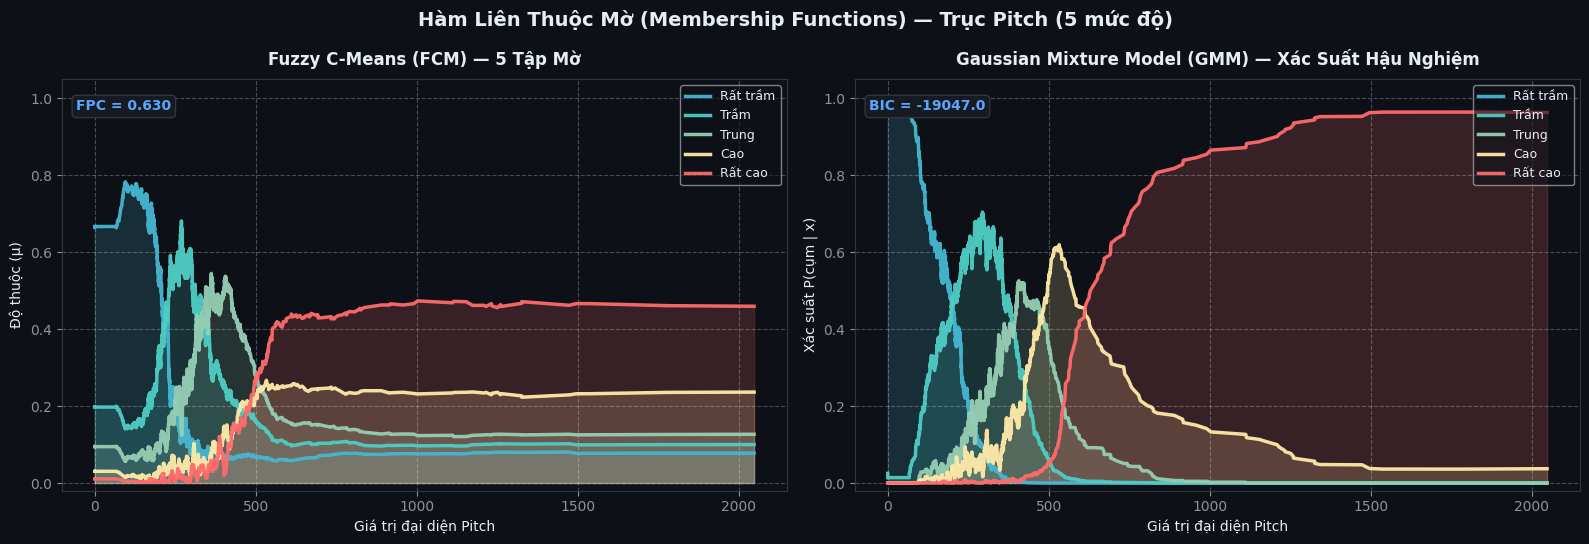

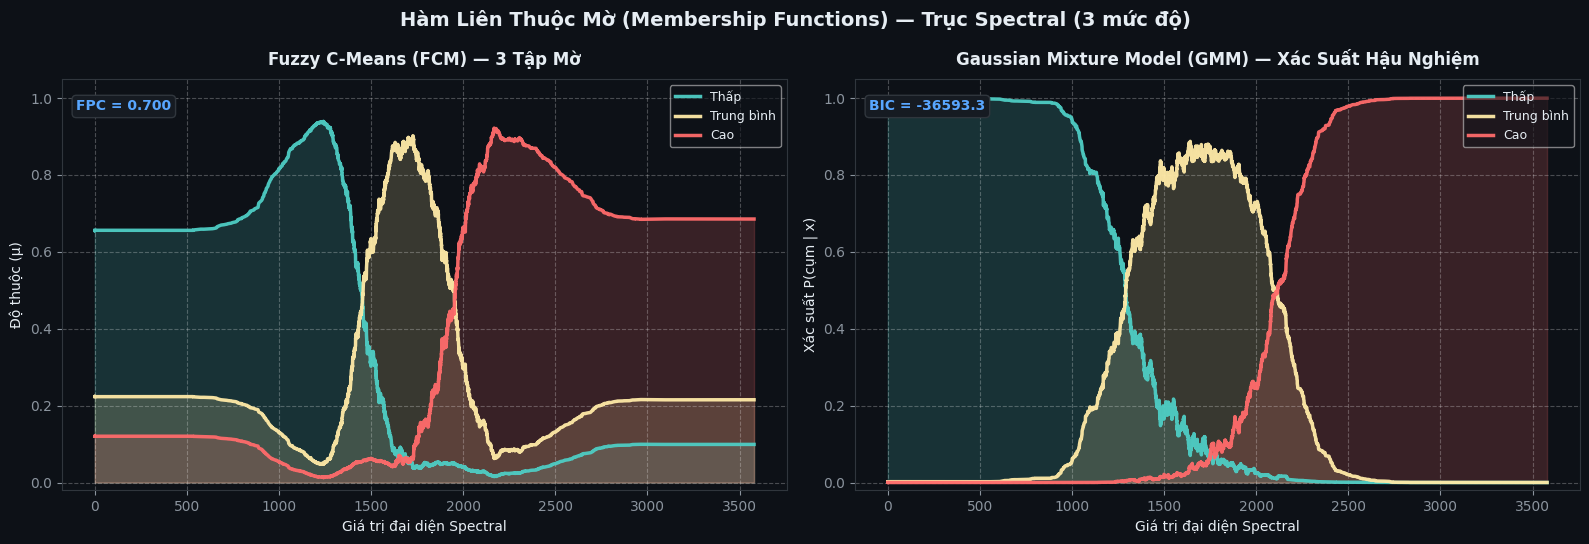

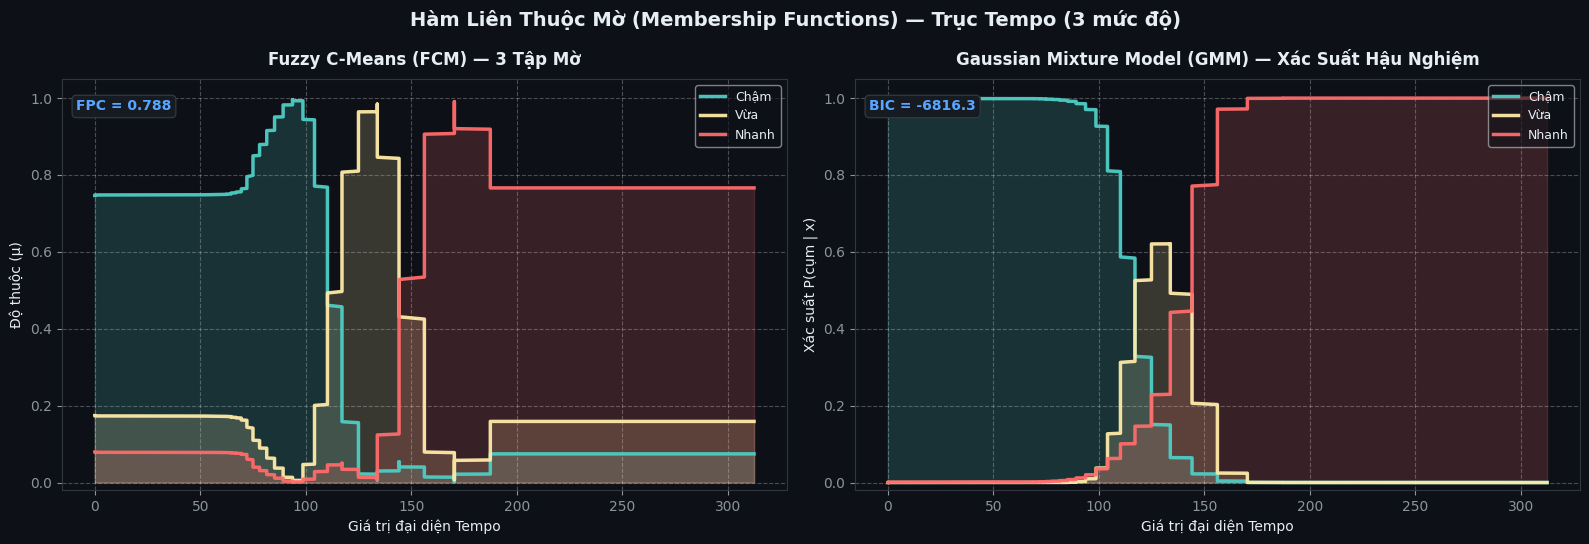

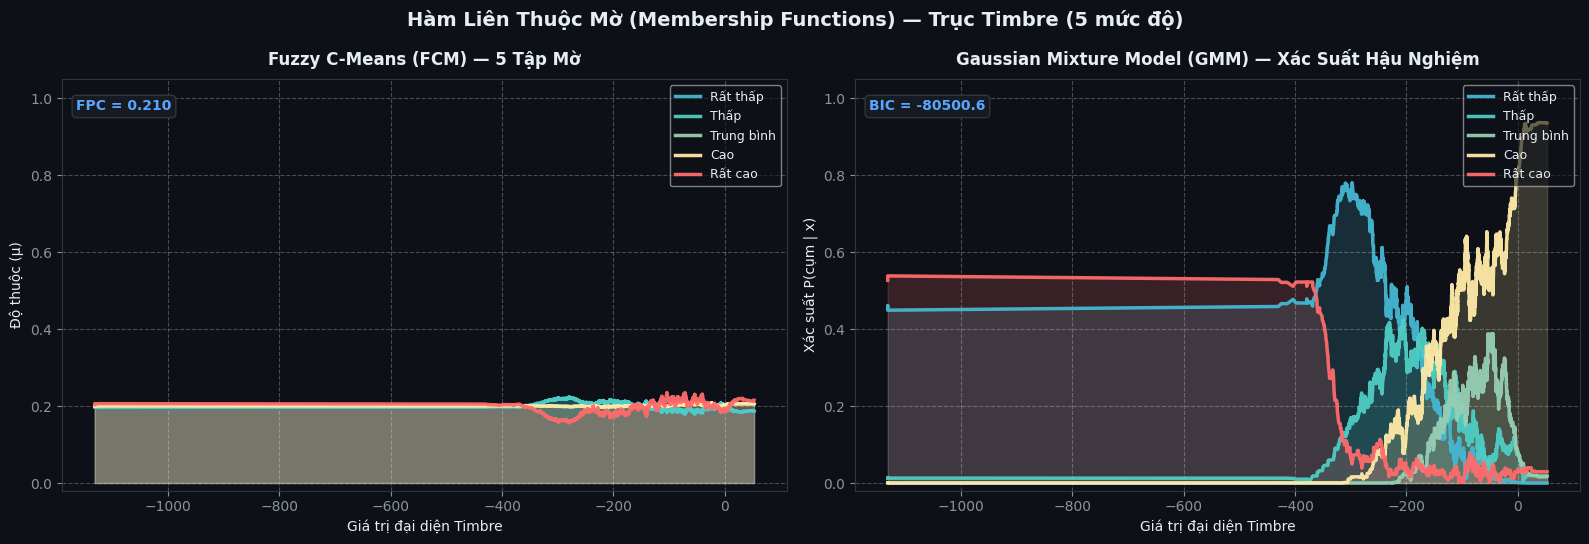

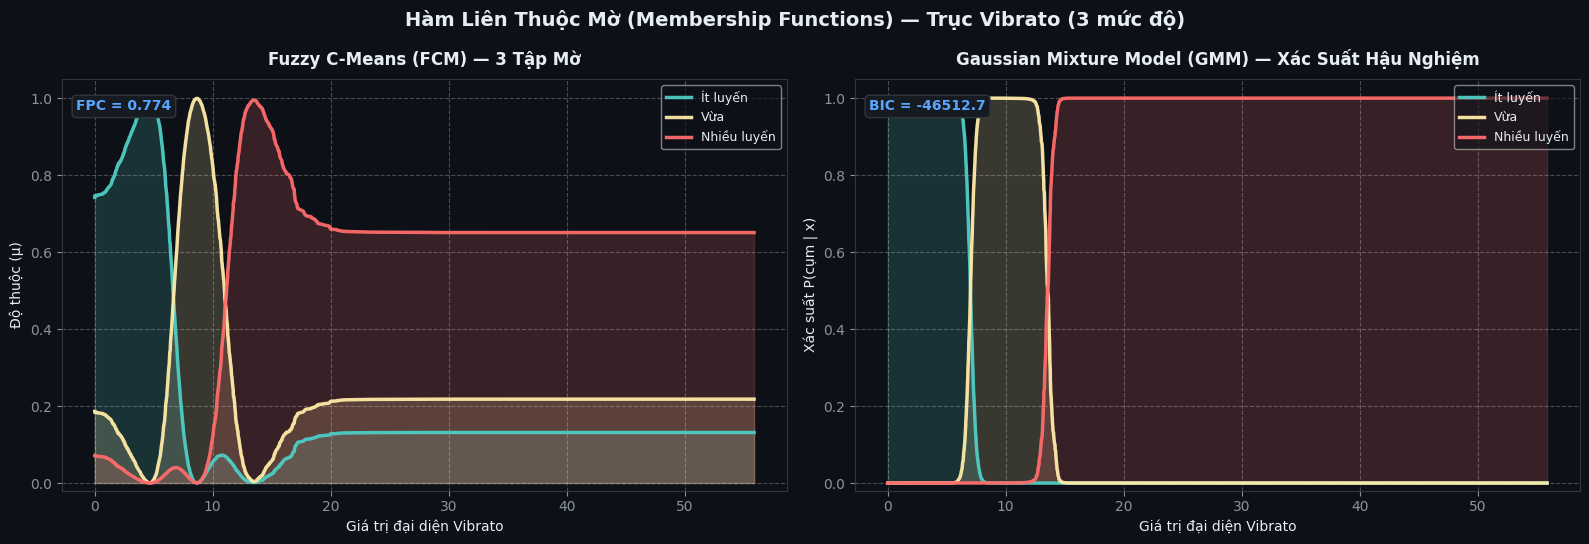

In [19]:
# Vẽ biểu đồ hàm liên thuộc mờ (Membership Functions) cho 7 trục đặc trưng (27 mức độ)
from scipy.ndimage import uniform_filter1d

PALETTE_3 = ['#4ECDC4', '#FFEAA7', '#FF6B6B']
PALETTE_5 = ['#45B7D1', '#4ECDC4', '#96CEB4', '#FFEAA7', '#FF6B6B']

def plot_membership(ax_name, fcm, gmm_r, fvals):
    fvals = np.nan_to_num(fvals)
    k = fcm['k'] if fcm else (gmm_r['k'] if gmm_r else 3)
    
    # Lấy danh sách tên mức độ ngữ nghĩa an toàn
    names = MUSIC_L.get(ax_name, {}).get(k)
    if names is None and fcm and 'names' in fcm:
        names = list(fcm['names'].values())
    if names is None and gmm_r and 'names' in gmm_r:
        names = list(gmm_r['names'].values())
    if names is None:
        names = [f'Mức {i+1}' for i in range(k)]
        
    colors = PALETTE_5 if k == 5 else PALETTE_3
    
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5.5), facecolor='#0d1117')
    fig.suptitle(f'Hàm Liên Thuộc Mờ (Membership Functions) — Trục {ax_name} ({k} mức độ)',
                 fontsize=14, fontweight='bold', color='#e6edf3', y=0.98)
    
    sidx = np.argsort(fvals)
    xs = fvals[sidx]
    smooth_w = max(5, len(sidx) // 40)

    # 1. Fuzzy C-Means (FCM)
    if fcm:
        # Lấy sorted_idx hoặc tự động tính nếu chưa có
        if 'sorted_idx' in fcm:
            sorted_idx_fcm = fcm['sorted_idx']
        elif 'centers' in fcm:
            sorted_idx_fcm = np.argsort(fcm['centers'].mean(axis=1))
        else:
            sorted_idx_fcm = list(range(k))
            
        for i in range(k):
            c_orig = sorted_idx_fcm[i]
            label_name = names[i]
            us = uniform_filter1d(fcm['membership'][c_orig, sidx], size=smooth_w)
            a1.plot(xs, us, color=colors[i], lw=2.5, label=label_name, alpha=0.95)
            a1.fill_between(xs, us, alpha=0.18, color=colors[i])
        a1.set_title(f'Fuzzy C-Means (FCM) — {k} Tập Mờ', fontsize=12, fontweight='bold', pad=10)
        a1.set_ylim(-0.02, 1.05)
        a1.set_xlabel(f'Giá trị đại diện {ax_name}')
        a1.set_ylabel('Độ thuộc (μ)')
        a1.legend(loc='upper right', framealpha=0.6, fontsize=9)
        a1.grid(alpha=0.25, linestyle='--')
        a1.text(0.02, 0.95, f'FPC = {fcm["fpc"]:.3f}', transform=a1.transAxes, ha='left', va='top',
                color='#58a6ff', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#161b22', edgecolor='#30363d'))

    # 2. Gaussian Mixture Model (GMM)
    if gmm_r:
        # Lấy sorted_idx hoặc tự động tính nếu chưa có
        if 'sorted_idx' in gmm_r:
            sorted_idx_gmm = gmm_r['sorted_idx']
        elif 'model' in gmm_r:
            sorted_idx_gmm = np.argsort(gmm_r['model'].means_.mean(axis=1))
        else:
            sorted_idx_gmm = list(range(k))
            
        for i in range(k):
            c_orig = sorted_idx_gmm[i]
            label_name = names[i]
            ps = uniform_filter1d(gmm_r['probs'][sidx, c_orig], size=smooth_w)
            a2.plot(xs, ps, color=colors[i], lw=2.5, label=label_name, alpha=0.95)
            a2.fill_between(xs, ps, alpha=0.18, color=colors[i])
        a2.set_title('Gaussian Mixture Model (GMM) — Xác Suất Hậu Nghiệm', fontsize=12, fontweight='bold', pad=10)
        a2.set_ylim(-0.02, 1.05)
        a2.set_xlabel(f'Giá trị đại diện {ax_name}')
        a2.set_ylabel('Xác suất P(cụm | x)')
        a2.legend(loc='upper right', framealpha=0.6, fontsize=9)
        a2.grid(alpha=0.25, linestyle='--')
        a2.text(0.02, 0.95, f'BIC = {gmm_r["bic"]:.1f}', transform=a2.transAxes, ha='left', va='top',
                color='#58a6ff', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#161b22', edgecolor='#30363d'))

    plt.tight_layout()
    plt.savefig(f'./data/plots/membership_{ax_name.lower()}.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()

for ax_name in FUZZY_AXES:
    vf = [f for f in FUZZY_AXES[ax_name] if f in feat_col_idx]
    if vf and vf[0] in df.columns:
        plot_membership(ax_name, fcm_res.get(ax_name),
                        gmm_res.get(ax_name), df[vf[0]].fillna(0).values)


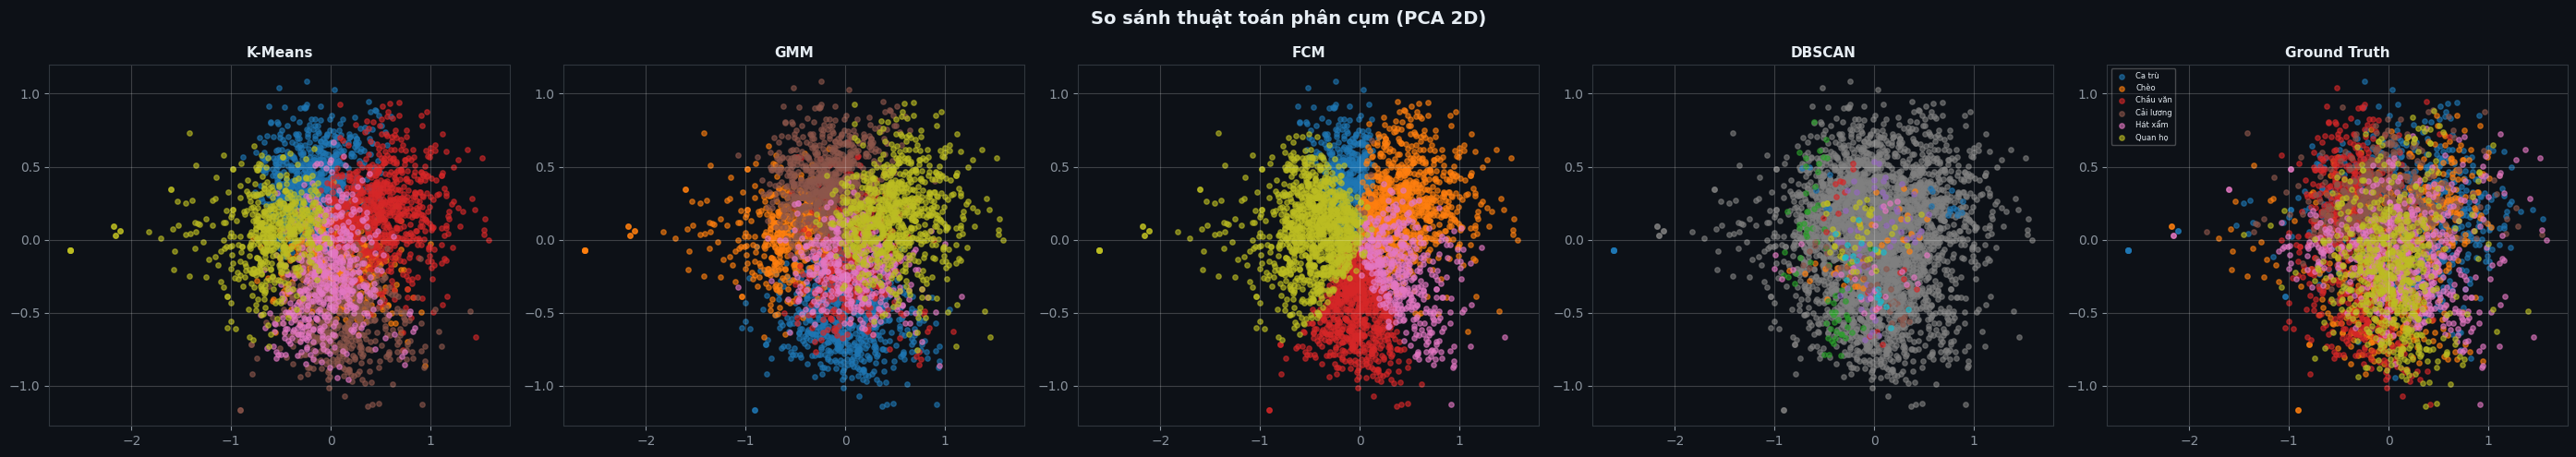

Saved: ./data/07_clustering_comparison.png


In [20]:
# So sánh 4 thuật toán + Ground Truth trên PCA 2D
pca2  = PCA(n_components=2, random_state=42)
X2d   = pca2.fit_transform(np.nan_to_num(Xs))
K     = len(df['label'].unique())
le    = LabelEncoder()
ytrue = le.fit_transform(df['label'].values)

km_lbl  = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(np.nan_to_num(Xs))
gmm_g   = GaussianMixture(n_components=K, random_state=42, n_init=5).fit(np.nan_to_num(Xs))
gmm_lbl = gmm_g.predict(np.nan_to_num(Xs))
_, ug, _, _, _, _, _ = cmeans(np.nan_to_num(Xs).T, c=K, m=2.0, error=0.005, maxiter=500, seed=42)
fcm_lbl = np.argmax(ug, axis=0)
db_lbl  = DBSCAN(eps=0.8, min_samples=5).fit_predict(np.nan_to_num(Xs))

all_algos = [('K-Means',km_lbl),('GMM',gmm_lbl),('FCM',fcm_lbl),
             ('DBSCAN',db_lbl),('Ground Truth',ytrue)]
cmap_tab = plt.cm.get_cmap('tab10')

fig, axs = plt.subplots(1, 5, figsize=(28, 5), facecolor='#0d1117')
fig.suptitle('So sánh thuật toán phân cụm (PCA 2D)', fontsize=14, fontweight='bold', color='#e6edf3')

for ax, (name, lbls) in zip(axs, all_algos):
    ul = np.unique(lbls)
    for i, lbl in enumerate(ul):
        mask = lbls==lbl
        c    = 'gray' if lbl==-1 else cmap_tab(i/max(len(ul),1))
        nm   = le.classes_[lbl] if name=='Ground Truth' and lbl>=0 else str(lbl)
        ax.scatter(X2d[mask,0],X2d[mask,1],c=[c],s=15,alpha=0.6,
                   label=nm if name=='Ground Truth' else None)
    ax.set_title(name,fontsize=11,color='#e6edf3',fontweight='bold'); ax.grid(alpha=0.2)
    if name=='Ground Truth': ax.legend(fontsize=6,framealpha=0.3)

plt.tight_layout()
plt.savefig('./data/plots/07_clustering_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/plots/07_clustering_comparison.png')

## Bước 5: Bảng Tổng Hợp Hồ Sơ Mờ

In [21]:
# Tổng hợp hồ sơ mờ theo thể loại
genre_profile = {}
for genre in df['label'].unique():
    mask = df['label'].values == genre
    gp = {}
    for ax_name, fcm in fcm_res.items():
        u   = fcm['membership']
        u_g = u[:, mask].mean(axis=1)
        dom = np.argmax(u_g)
        gp[ax_name] = dict(
            dominant=fcm['names'].get(dom,f'Cụm {dom}'),
            score=float(u_g[dom]),
            all={fcm['names'].get(c,f'Cụm {c}'): round(float(u_g[c]),3) for c in range(fcm['k'])}
        )
    genre_profile[genre] = gp

print('='*95)
print(f'{"Thể loại":25s}', end='')
for ax in fcm_res: print(f'  {ax:12s}', end='')
print()
print('-'*95)
for genre, gp in genre_profile.items():
    print(f'{genre:25s}', end='')
    for ax in fcm_res:
        if ax in gp: print(f'  {gp[ax]["dominant"]:7s}({gp[ax]["score"]:.2f})', end='')
        else:        print(f'  {"N/A":12s}', end='')
    print()
print('='*95)

Thể loại                   Energy        Harmony       Pitch         Spectral      Tempo         Timbre        Vibrato     
-----------------------------------------------------------------------------------------------
Ca trù                     Rất yếu(0.43)  Thấp   (0.33)  Trầm   (0.55)  Trung bình(0.41)  Vừa    (0.46)  Rất thấp(0.22)  Vừa    (0.53)
Chèo                       Vừa    (0.26)  Cao    (0.33)  Trung  (0.37)  Trung bình(0.61)  Chậm   (0.39)  Rất thấp(0.22)  Vừa    (0.42)
Chầu văn                   Yếu    (0.40)  Cao    (0.33)  Rất trầm(0.53)  Trung bình(0.44)  Vừa    (0.42)  Rất cao(0.22)  Ít luyến(0.66)
Cải lương                  Yếu    (0.29)  Cao    (0.33)  Trầm   (0.44)  Trung bình(0.42)  Chậm   (0.39)  Rất cao(0.25)  Vừa    (0.48)
Hát xẩm                    Rất mạnh(0.26)  Thấp   (0.33)  Trầm   (0.44)  Trung bình(0.47)  Nhanh  (0.35)  Rất thấp(0.22)  Vừa    (0.47)
Quan họ                    Mạnh   (0.43)  Thấp   (0.33)  Trung  (0.34)  Trung bình(0.58)  Vừa    (0.79) 

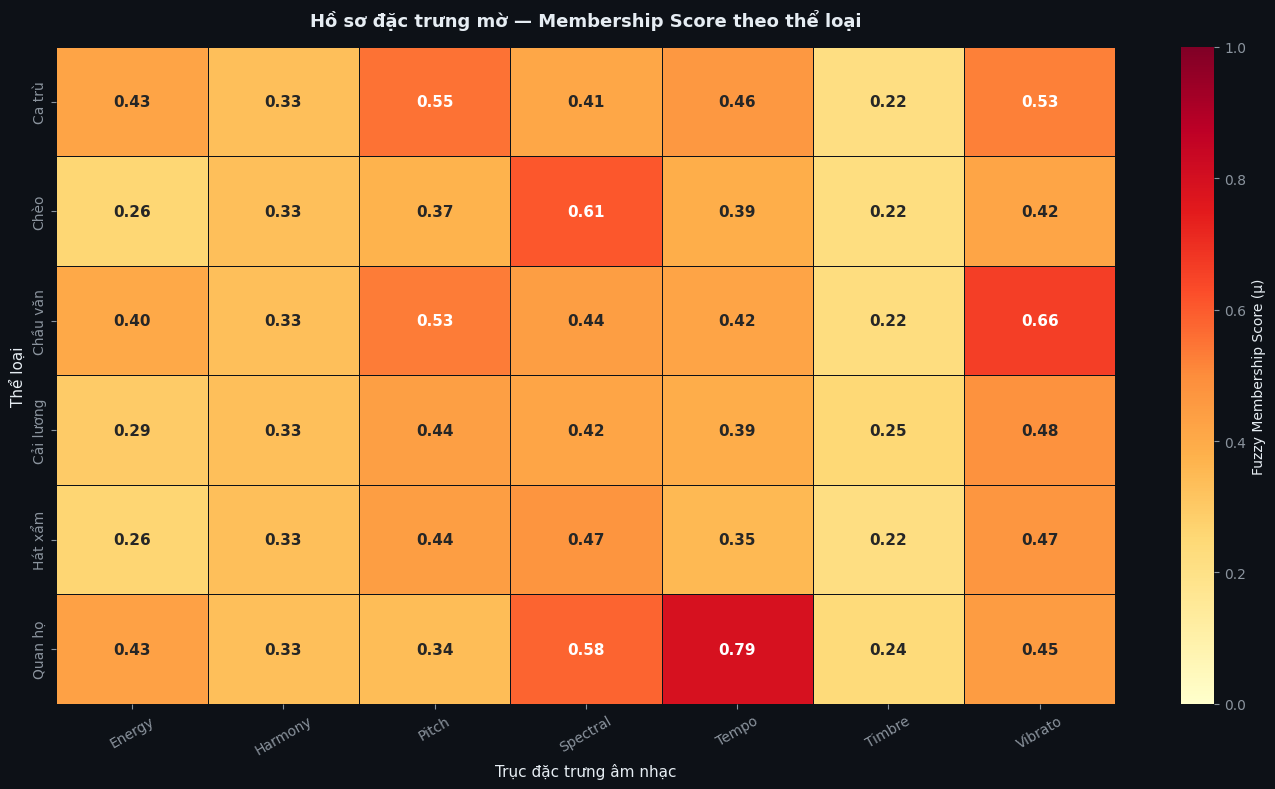

Saved: ./data/08_fuzzy_profile_heatmap.png


In [22]:
# Heatmap hồ sơ mờ
rows = [{'Thể loại': genre, **{ax: info['score'] for ax, info in gp.items()}}
        for genre, gp in genre_profile.items()]
df_hm = pd.DataFrame(rows).set_index('Thể loại')

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0d1117')
sns.heatmap(df_hm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, linecolor='#0d1117',
            annot_kws={'size':11,'weight':'bold'},
            cbar_kws={'label':'Fuzzy Membership Score (μ)'})
ax.set_title('Hồ sơ đặc trưng mờ — Membership Score theo thể loại',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trục đặc trưng âm nhạc', fontsize=11)
ax.set_ylabel('Thể loại', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('./data/plots/08_fuzzy_profile_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: ./data/plots/08_fuzzy_profile_heatmap.png')

In [23]:
# ============================================================
# LƯU KẾT QUẢ PHÂN CỤM & TẠO 2 BẢNG DỮ LIỆU MỜ (3,600 MẪU)
# 1. features_fuzzy_crisp.csv (7 cột nhãn chữ ngữ nghĩa)
# 2. features_fuzzy_continuous.csv (27 cột liên thuộc mờ liên tục [0, 1])
# ============================================================
out = {g: {'name':g,'axes':{ax:{'dominant':info['dominant'],
            'score':round(info['score'],4),'all':info['all']}
            for ax,info in gp.items()}}
       for g, gp in genre_profile.items()}

with open('./data/models/fuzzy_profiles.json','w',encoding='utf-8') as f:
    json.dump(out, f, ensure_ascii=False, indent=2)

fcm_save = {k:{kk:vv for kk,vv in v.items()} for k,v in fcm_res.items()}
with open('./data/models/fcm_results.pkl','wb') as f: pickle.dump(fcm_save,f)
with open('./data/models/gmm_results.pkl','wb') as f: pickle.dump(gmm_res,f)

# --- SINH 2 TẬP DỮ LIỆU MỜ ---
print('\nĐang sinh 2 tập dữ liệu mờ features_fuzzy_crisp.csv và features_fuzzy_continuous.csv...')

crisp_dict = {
    'sample_idx': df['sample_idx'],
    'label': df['label'],
    'audio_path': df.get('audio_path', ''),
    'segment_id': df.get('segment_id', 1)
}
continuous_dict = {
    'sample_idx': df['sample_idx'],
    'label': df['label'],
    'audio_path': df.get('audio_path', ''),
    'segment_id': df.get('segment_id', 1)
}
total_continuous_feats = 0

for ax_name, k in FUZZY_LEVELS.items():
    fcm = fcm_res[ax_name]
    u = fcm['membership']      # (k, n_samples)
    cnames = fcm['names']      # mapping cluster_idx -> nhãn ngôn ngữ
    
    # 1. Nhãn Crisp cứng (argmax membership)
    hard_idx = np.argmax(u, axis=0)
    crisp_dict[ax_name] = [cnames[idx] for idx in hard_idx]
    
    # 2. Giá trị liên thuộc mờ liên tục [0, 1] cho từng mức độ
    names = MUSIC_L[ax_name][k]
    for lvl_name in names:
        c_idx = next(idx for idx, name in cnames.items() if name == lvl_name)
        col_name = f"{ax_name}_{lvl_name}".replace(' ', '_')
        continuous_dict[col_name] = np.round(u[c_idx, :], 4)
        total_continuous_feats += 1

df_crisp = pd.DataFrame(crisp_dict)
df_continuous = pd.DataFrame(continuous_dict)

# Ghi đè 2 file dữ liệu mờ
df_crisp.to_csv('./data/datasets/features_fuzzy_crisp.csv', index=False)
df_continuous.to_csv('./data/datasets/features_fuzzy_continuous.csv', index=False)

print('='*70)
print('ĐÃ HOÀN TẤT VÀ LƯU THÀNH CÔNG TẤT CẢ DỮ LIỆU:')
print(f'  1. ./data/datasets/features_all.csv: {df.shape[0]} mẫu × {df.shape[1]} đặc trưng gốc')
print(f'  2. ./data/datasets/features_fuzzy_crisp.csv: {df_crisp.shape[0]} mẫu × {df_crisp.shape[1]} cột (7 trục nhãn chữ)')
print(f'  3. ./data/datasets/features_fuzzy_continuous.csv: {df_continuous.shape[0]} mẫu × {df_continuous.shape[1]} cột ({total_continuous_feats} mức độ mờ)')
print(f'  4. ./data/datasets/holdout_samples_for_inference.csv: {len(df_holdout)} bài hát độc lập (3 bài/thể loại dành riêng)')
print(f'  5. ./data/models/fuzzy_profiles.json')
print(f'  6. ./data/models/fcm_results.pkl & gmm_results.pkl')
print('='*70)
print('Các biểu đồ đã cập nhật và lưu đè:')
for p in sorted(Path('./data/plots').glob('*.png')):
    print(f'  - {p.name}')
print('\n🎉 HOÀN THÀNH BƯỚC 1! Dữ liệu đã sẵn sàng cho 02_fuzzy_decision_tree_random_forest.ipynb.')



Đang sinh 2 tập dữ liệu mờ features_fuzzy_crisp.csv và features_fuzzy_continuous.csv...
ĐÃ HOÀN TẤT VÀ LƯU THÀNH CÔNG TẤT CẢ DỮ LIỆU:
  1. ./data/features_all.csv: 3600 mẫu × 172 đặc trưng gốc
  2. ./data/features_fuzzy_crisp.csv: 3600 mẫu × 11 cột (7 trục nhãn chữ)
  3. ./data/features_fuzzy_continuous.csv: 3600 mẫu × 31 cột (27 mức độ mờ)
  4. ./data/holdout_samples_for_inference.csv: 18 bài hát độc lập (3 bài/thể loại dành riêng)
  5. ./data/fuzzy_profiles.json
  6. ./data/fcm_results.pkl & gmm_results.pkl
Các biểu đồ đã cập nhật và lưu đè:
  - 01_genre_distribution.png
  - 02_violin_comparison.png
  - 03_radar_chart.png
  - 04_pca_tsne.png
  - 05_correlation.png
  - 06_optimal_k.png
  - 07_clustering_comparison.png
  - 08_fuzzy_profile_heatmap.png
  - 09_decision_tree_crisp_graph.png
  - 10_decision_tree_continuous_graph.png
  - 11_rf_feature_importance.png
  - 12_model_performance_comparison.png
  - membership_energy.png
  - membership_harmony.png
  - membership_pitch.png
  - mem